#### Imputation approach that combines temporal matrix with SVD and KNN
This no This Notebook is for testing and validating new imputation approach that combines temporal matrix with SVD and KNN
#
The objective is to substantiate the new approach by testing, constructing the mathematics behind and trying to find logical errors

In [1]:
# the data must be after throughput pre-processing
DATA_DIR = "./temporal_svd_knn_ds/" 

In [2]:
import pandas as pd
import numpy as np 
import os
from typing import Optional, Tuple, Dict


Documenting data that is being used

In [3]:
for root, _, files in os.walk(DATA_DIR):
    for file in files:
        if file.endswith(".csv"):
            filepath = os.path.join(root, file)
            print(f"\n📂 File: {filepath}")

            df = pd.read_csv(filepath)

            # Parse datetime, sort, and diff
            df["time"] = pd.to_datetime(df["time"], errors="coerce")
            df = df.dropna(subset=["time"]).sort_values("time")

            diffs = df["time"].diff().dropna()
            if diffs.empty:
                print("  ⚠️ Not enough rows to compute intervals.")
                continue

            vc = diffs.value_counts().sort_values(ascending=False)
            total = int(vc.sum())

            print(f"  Measurements found: {total}")
            print("  Interval breakdown:")
            for td, count in vc.items():
                secs = td.total_seconds()

                # Build readable label
                if secs % 86400 == 0:
                    n = int(secs // 86400); label = f"{n} day" + ("s" if n != 1 else "")
                elif secs % 3600 == 0:
                    n = int(secs // 3600); label = f"{n} hour" + ("s" if n != 1 else "")
                elif secs % 60 == 0:
                    n = int(secs // 60); label = f"{n} minute" + ("s" if n != 1 else "")
                elif secs.is_integer():
                    n = int(secs); label = f"{n} second" + ("s" if n != 1 else "")
                pct = 100 * count / total
                print(f"    • {label:<15} ({td}) — {count} ({pct:.2f}%)")


📂 File: ./temporal_svd_knn_ds/1.throughput.csv
  Measurements found: 6716
  Interval breakdown:
    • 1 hour          (0 days 01:00:00) — 6715 (99.99%)
    • 2 hours         (0 days 02:00:00) — 1 (0.01%)


In [4]:
import matplotlib.pyplot as plt
import pandas as pd
from matplotlib.dates import DateFormatter

In [5]:
def plot_throughput(df):
    df['timestamp'] = pd.to_datetime(df['time'])
    
    fig, ax = plt.subplots(figsize=(12, 6))
    ax.plot(df['timestamp'], df['throughput_bps'], color='purple', linewidth=0.5)
    
    ax.set_xlabel('timestamp')
    ax.set_ylabel('throughput')
    ax.grid(False)
    
    date_format = DateFormatter('%y-%m-%d')
    ax.xaxis.set_major_formatter(date_format)
    plt.xticks(rotation=45)
    
    plt.tight_layout()
    plt.show()

In [6]:
# seed for using always the same missing datasets
SEED = 42

# missing rates for experiments
MISSING_RATE = [0.1, 0.2, 0.3, 0.4]

THROUGHPUT_FEAT = "throughput_bps"

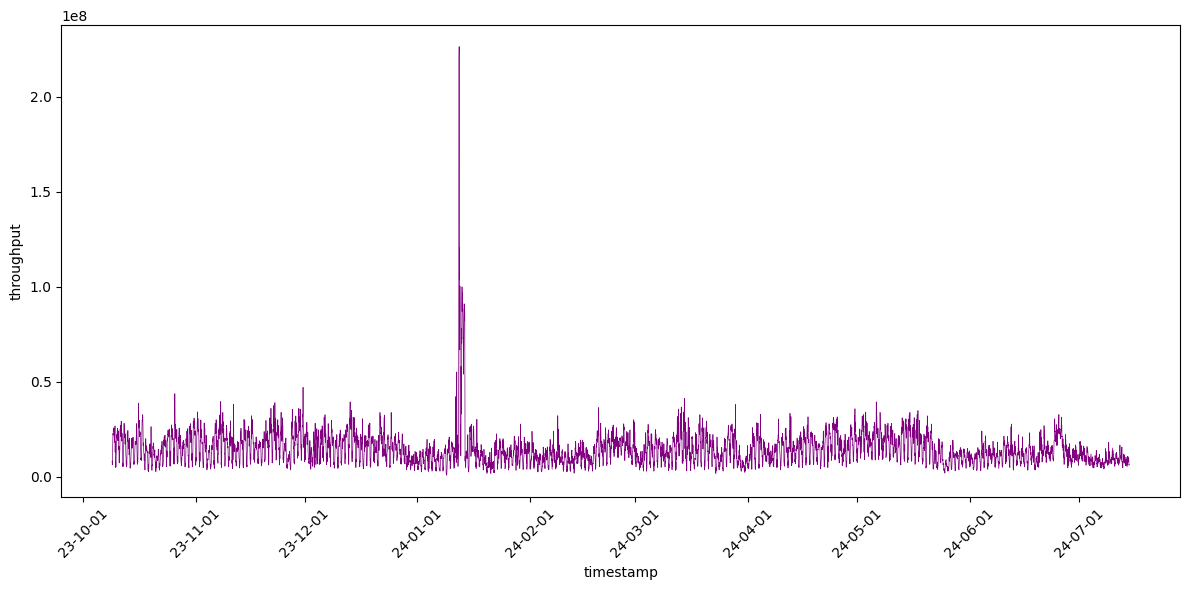

Introduced 10.0% missing data.


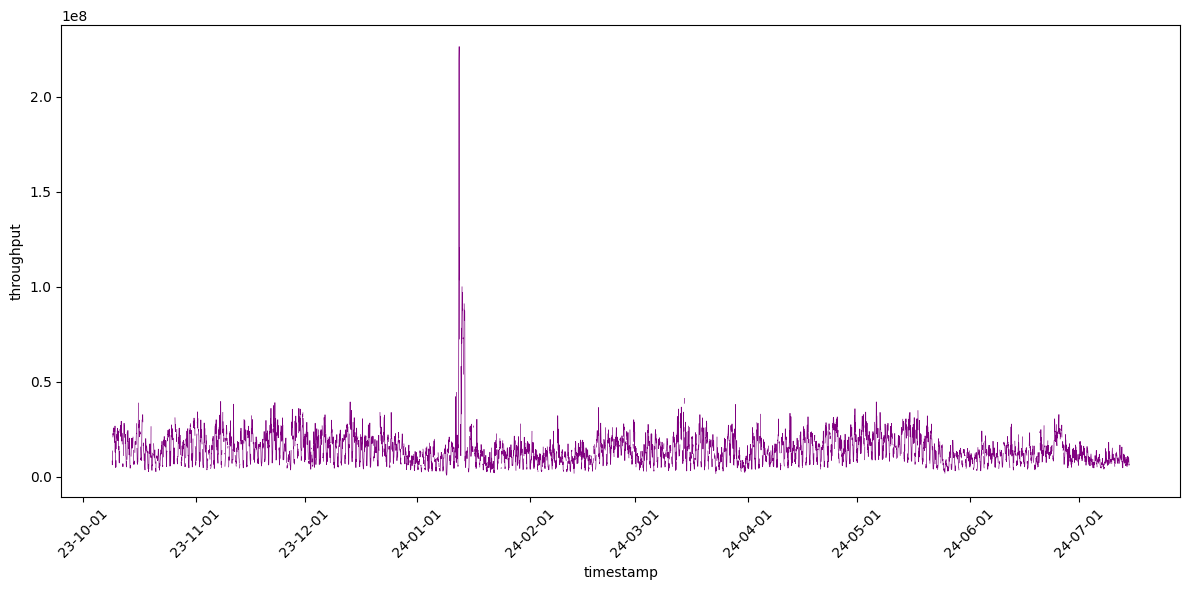

Introduced 20.0% missing data.


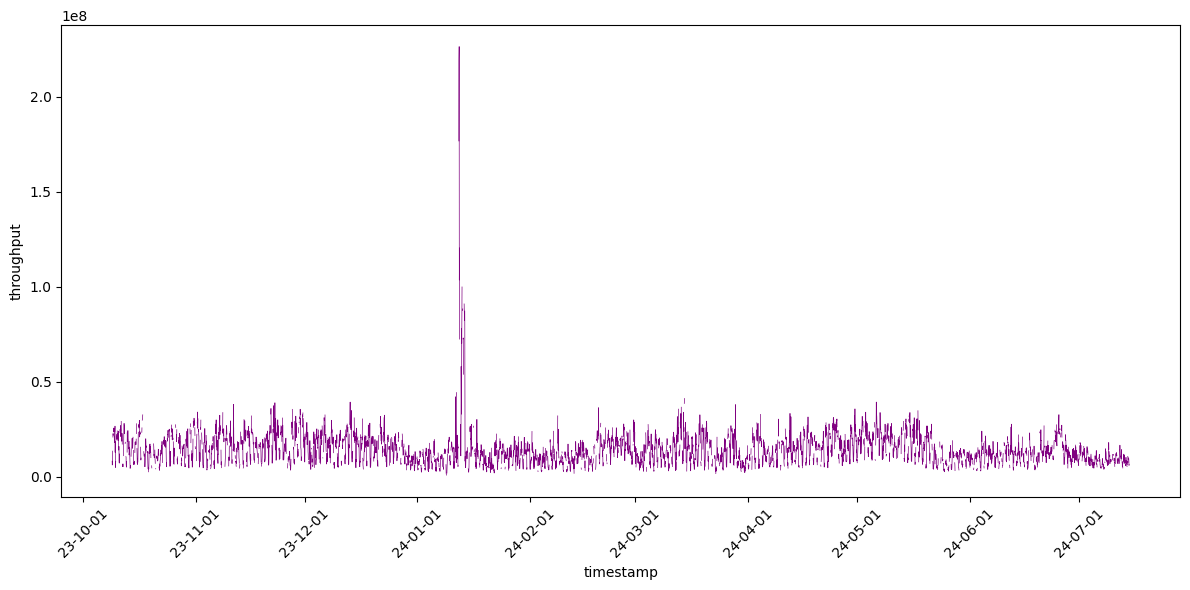

Introduced 30.0% missing data.


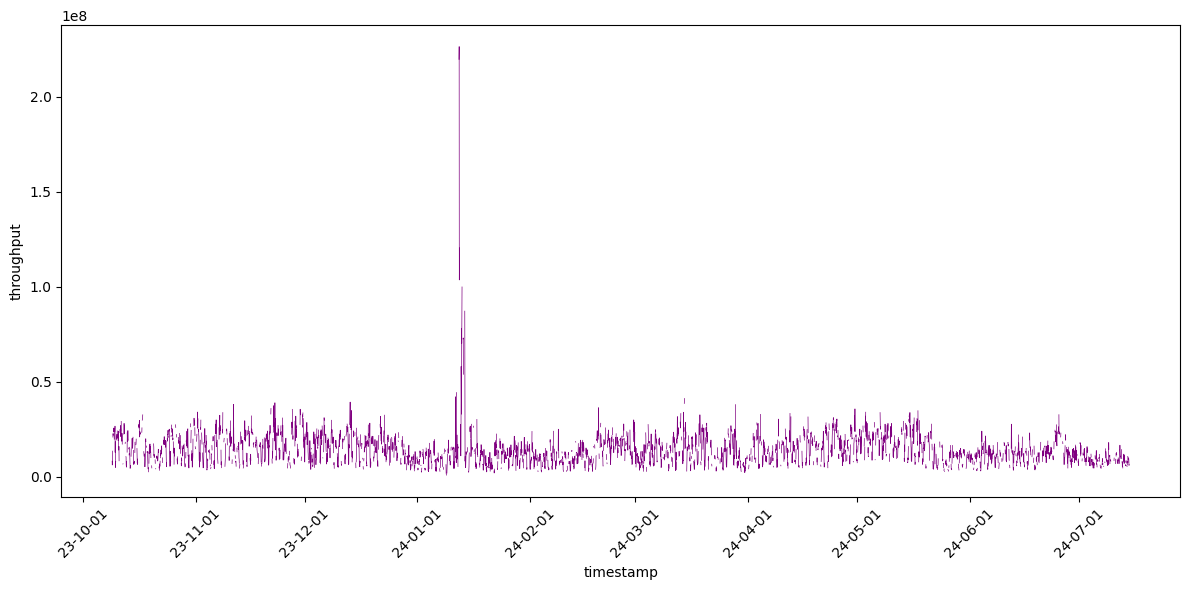

Introduced 40.0% missing data.


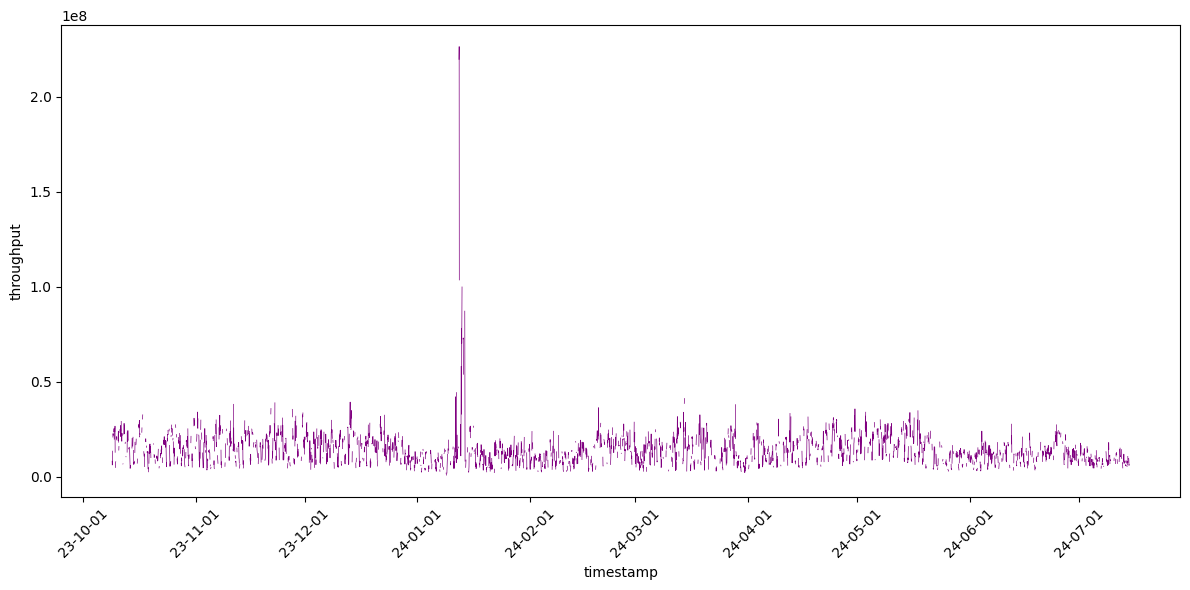

{'1': {'10':                            time  throughput_bps                 timestamp
  0     2023-10-09 00:00:00+00:00    8.276380e+06 2023-10-09 00:00:00+00:00
  1     2023-10-09 01:00:00+00:00    6.299608e+06 2023-10-09 01:00:00+00:00
  2     2023-10-09 02:00:00+00:00    7.835900e+06 2023-10-09 02:00:00+00:00
  3     2023-10-09 03:00:00+00:00    1.360294e+07 2023-10-09 03:00:00+00:00
  4     2023-10-09 04:00:00+00:00             NaN 2023-10-09 04:00:00+00:00
  ...                         ...             ...                       ...
  6712  2024-07-14 17:00:00+00:00    1.009773e+07 2024-07-14 17:00:00+00:00
  6713  2024-07-14 18:00:00+00:00    9.807295e+06 2024-07-14 18:00:00+00:00
  6714  2024-07-14 19:00:00+00:00    8.620658e+06 2024-07-14 19:00:00+00:00
  6715  2024-07-14 20:00:00+00:00    6.094621e+06 2024-07-14 20:00:00+00:00
  6716  2024-07-14 21:00:00+00:00    6.457880e+06 2024-07-14 21:00:00+00:00
  
  [6717 rows x 3 columns],
  '20':                            time  throug

In [7]:
# creating missing datasets for testing approach 
def introduce_missing_data(df, missing_rate, feature, seed):
    rng = np.random.default_rng(seed)
    df_missing = df.copy()
    mask = rng.random(len(df_missing)) < missing_rate
    df_missing.loc[mask, feature] = np.nan
    print(f"Introduced {missing_rate * 100}% missing data.")
    # print(f"Mask: {mask}") 
    return df_missing

datasets_missing = {}

for file in os.listdir(DATA_DIR):
    if file.endswith(".csv"):
        df = pd.read_csv(os.path.join(DATA_DIR, file))
        plot_throughput(df)
        base_key = file.removesuffix(".throughput.csv")  
        datasets_missing[base_key] = {} 
        
        for rate in MISSING_RATE:
            df_missing = introduce_missing_data(df, missing_rate=rate, feature=THROUGHPUT_FEAT, seed=SEED)
            plot_throughput(df_missing)
            rate_key = f"{int(rate * 100)}"
            datasets_missing[base_key][rate_key] = df_missing

datasets_missing  

In [8]:
import numpy as np
import pandas as pd

Testing if acf really is used

In [9]:
DATA_DIR = "./temporal_svd_knn_sample_ds"

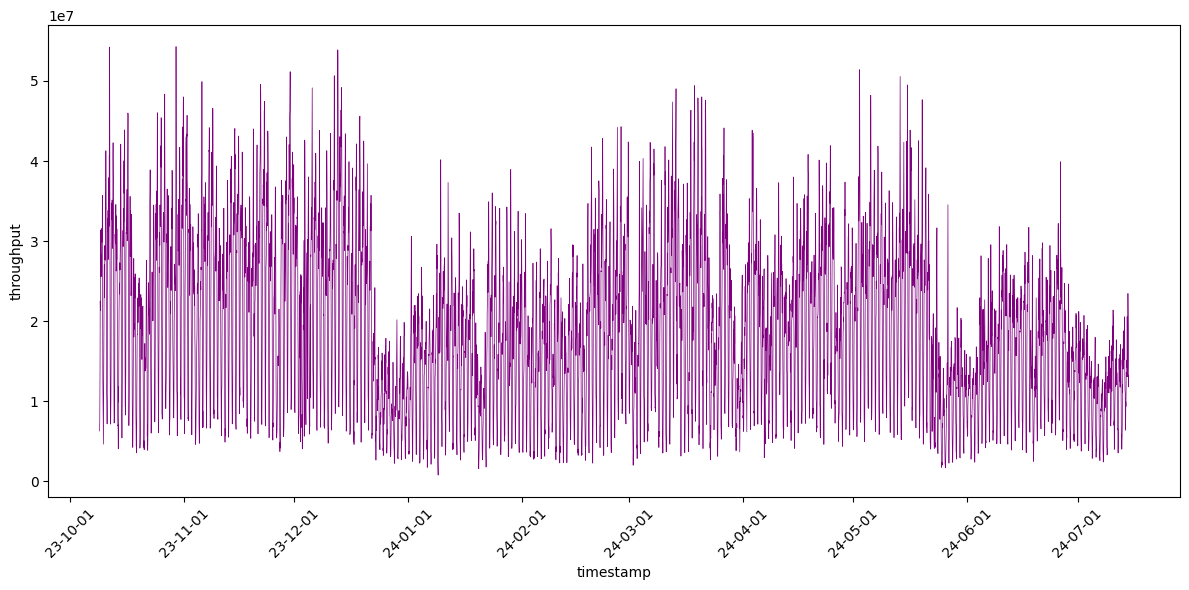

Introduced 10.0% missing data.
Introduced 20.0% missing data.
Introduced 30.0% missing data.
Introduced 40.0% missing data.


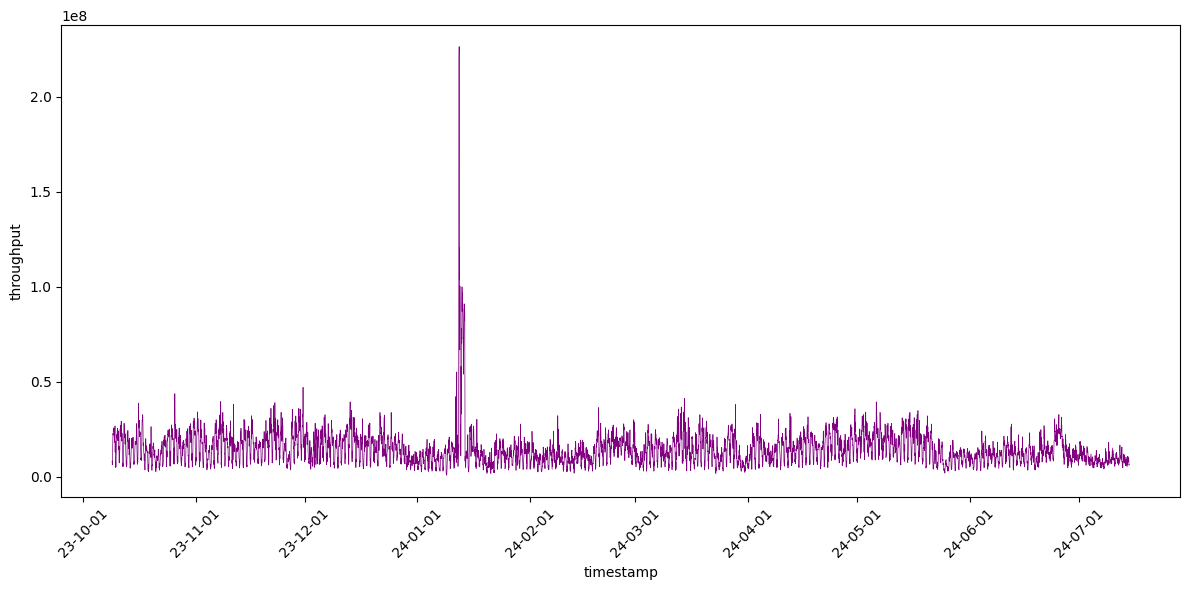

Introduced 10.0% missing data.
Introduced 20.0% missing data.
Introduced 30.0% missing data.
Introduced 40.0% missing data.


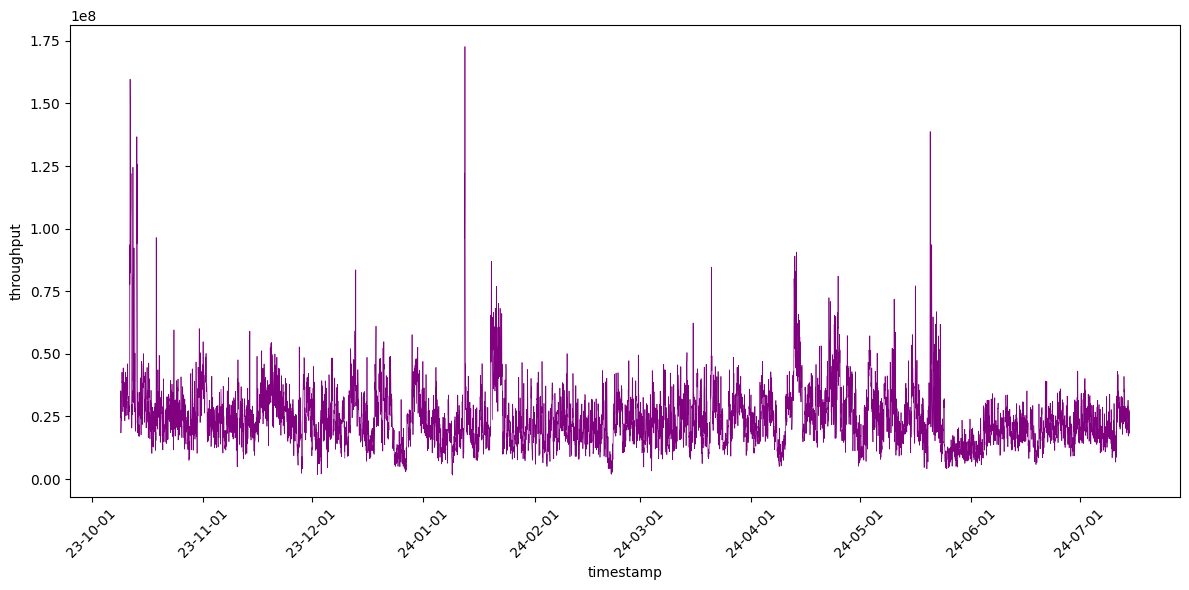

Introduced 10.0% missing data.
Introduced 20.0% missing data.
Introduced 30.0% missing data.
Introduced 40.0% missing data.


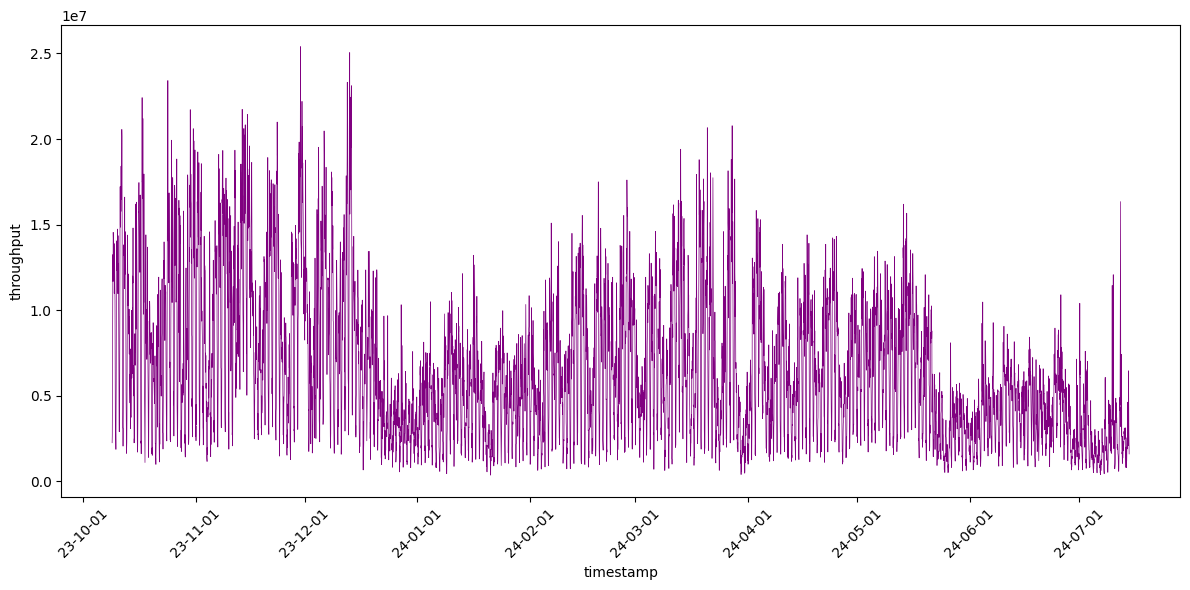

Introduced 10.0% missing data.
Introduced 20.0% missing data.
Introduced 30.0% missing data.
Introduced 40.0% missing data.


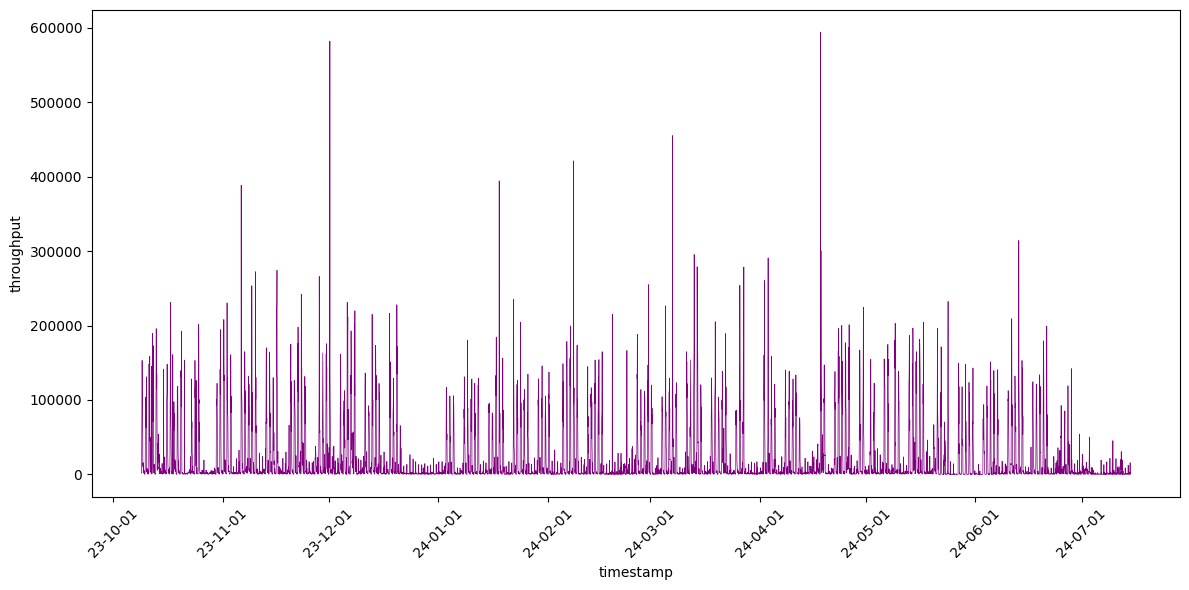

Introduced 10.0% missing data.
Introduced 20.0% missing data.
Introduced 30.0% missing data.
Introduced 40.0% missing data.


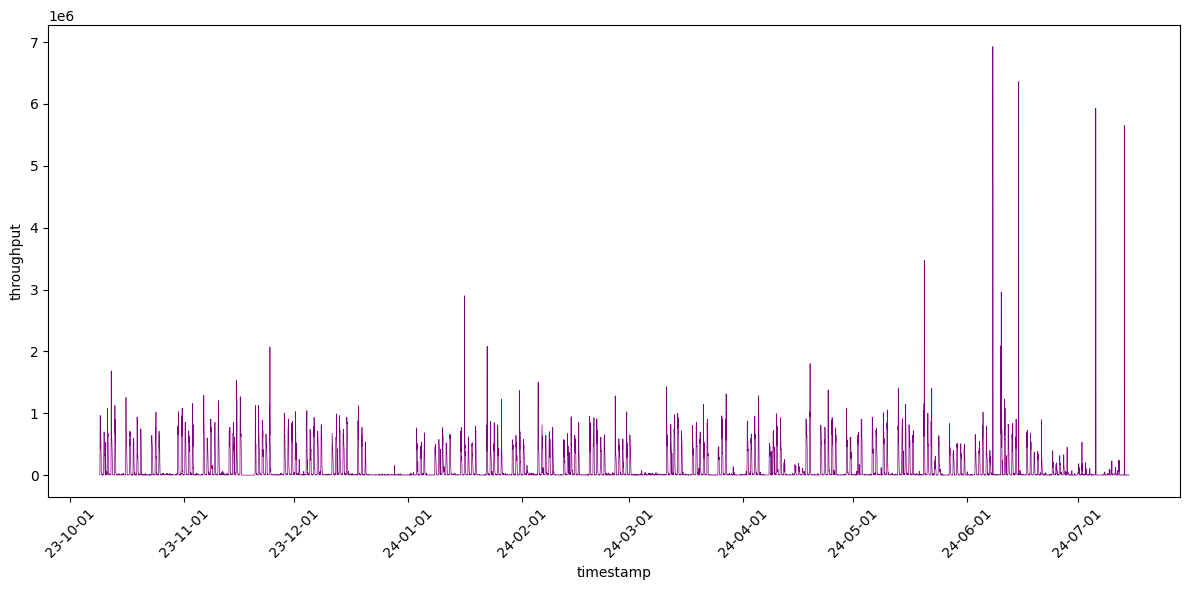

Introduced 10.0% missing data.
Introduced 20.0% missing data.
Introduced 30.0% missing data.
Introduced 40.0% missing data.


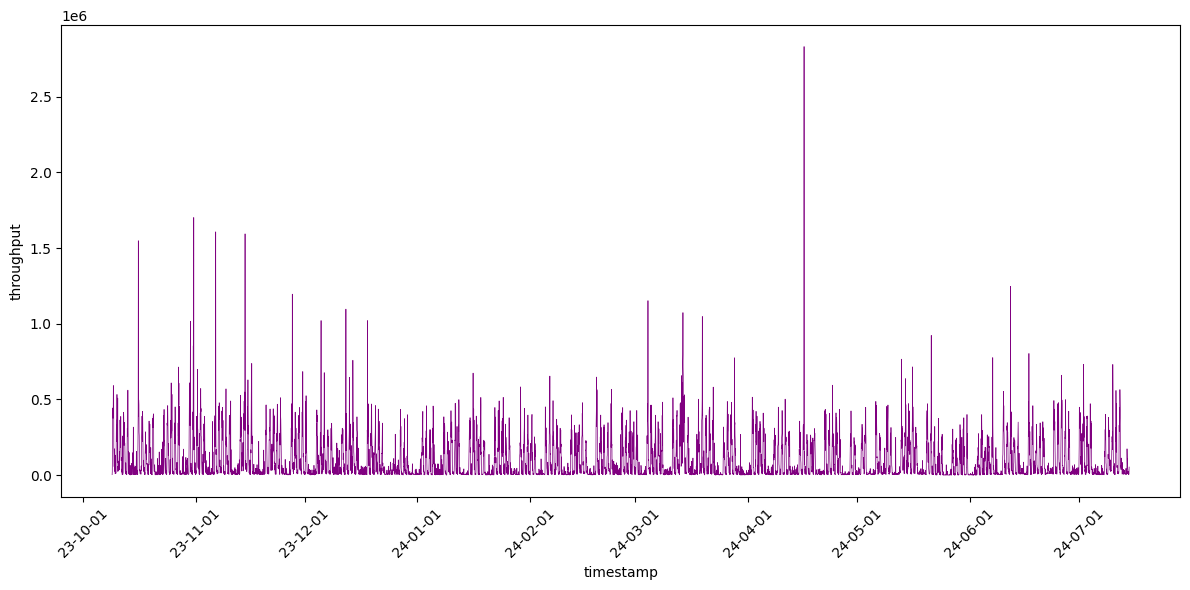

Introduced 10.0% missing data.
Introduced 20.0% missing data.
Introduced 30.0% missing data.
Introduced 40.0% missing data.


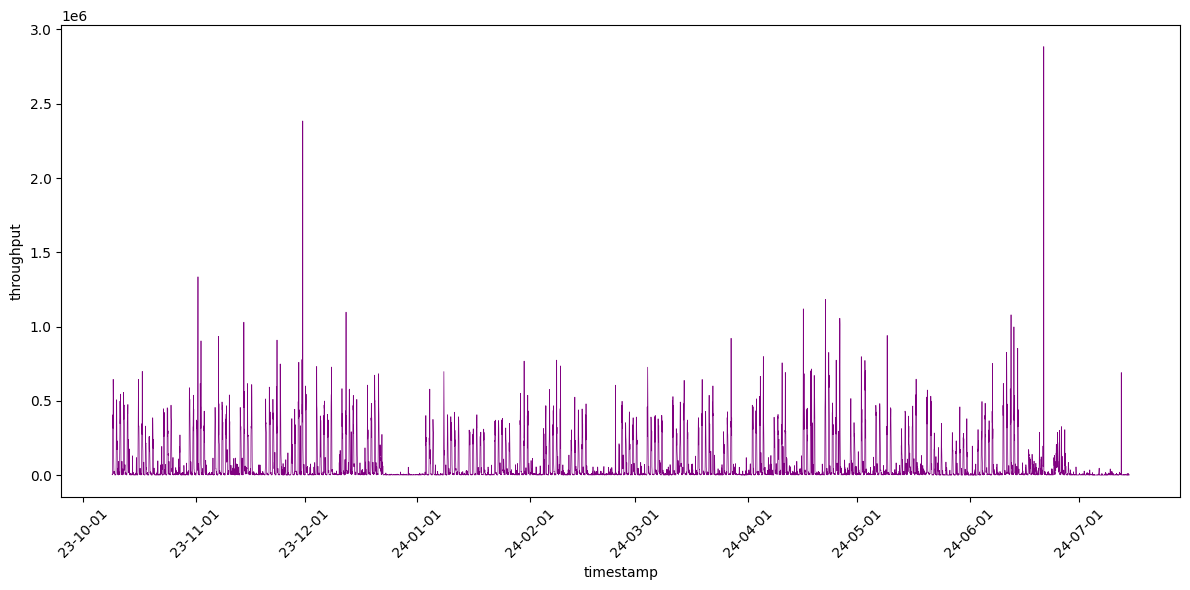

Introduced 10.0% missing data.
Introduced 20.0% missing data.
Introduced 30.0% missing data.
Introduced 40.0% missing data.


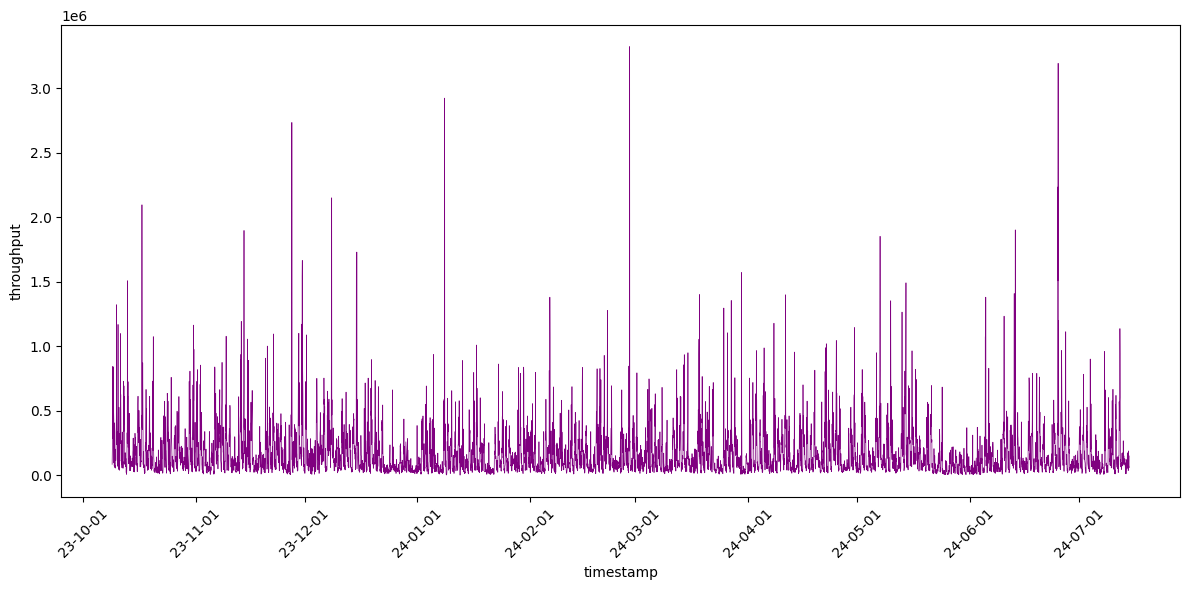

Introduced 10.0% missing data.
Introduced 20.0% missing data.
Introduced 30.0% missing data.
Introduced 40.0% missing data.


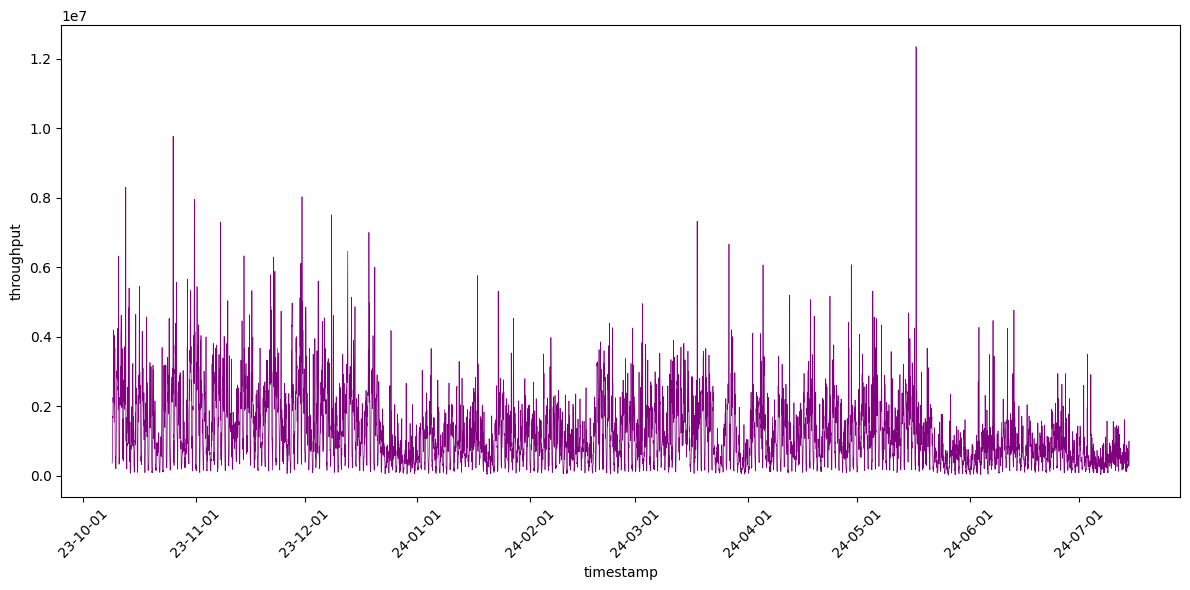

Introduced 10.0% missing data.
Introduced 20.0% missing data.
Introduced 30.0% missing data.
Introduced 40.0% missing data.


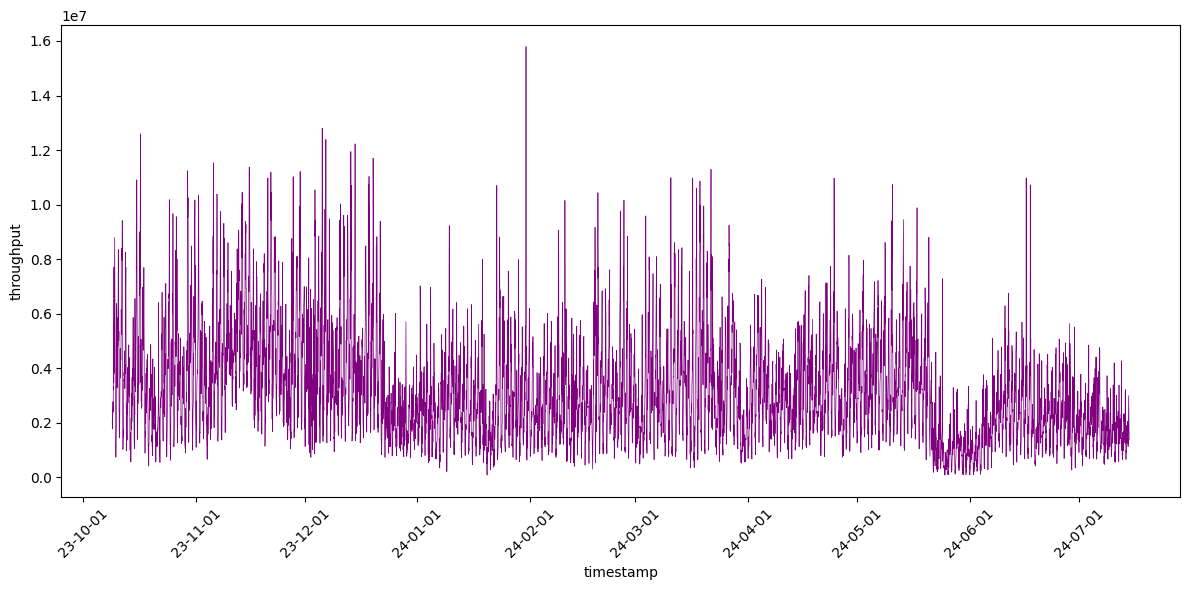

Introduced 10.0% missing data.
Introduced 20.0% missing data.
Introduced 30.0% missing data.
Introduced 40.0% missing data.


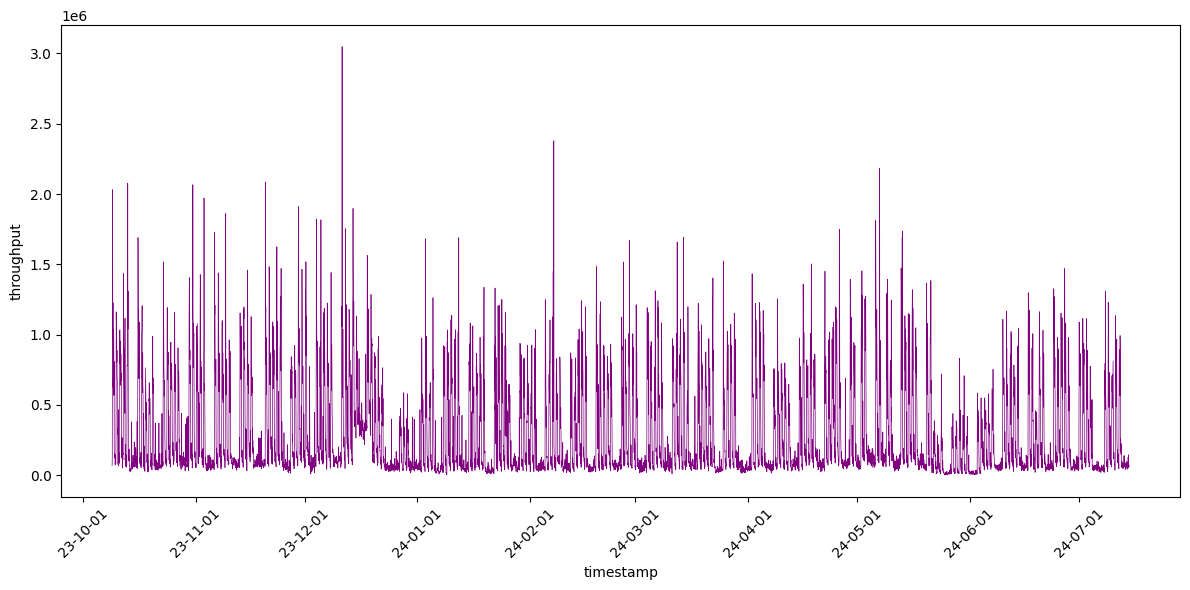

Introduced 10.0% missing data.
Introduced 20.0% missing data.
Introduced 30.0% missing data.
Introduced 40.0% missing data.


{'0': {'10':                            time  throughput_bps                 timestamp
  0     2023-10-09 00:00:00+00:00    6.291904e+06 2023-10-09 00:00:00+00:00
  1     2023-10-09 01:00:00+00:00    7.446471e+06 2023-10-09 01:00:00+00:00
  2     2023-10-09 02:00:00+00:00    1.002800e+07 2023-10-09 02:00:00+00:00
  3     2023-10-09 03:00:00+00:00    1.438063e+07 2023-10-09 03:00:00+00:00
  4     2023-10-09 04:00:00+00:00             NaN 2023-10-09 04:00:00+00:00
  ...                         ...             ...                       ...
  6712  2024-07-14 17:00:00+00:00    2.346846e+07 2024-07-14 17:00:00+00:00
  6713  2024-07-14 18:00:00+00:00    2.124341e+07 2024-07-14 18:00:00+00:00
  6714  2024-07-14 19:00:00+00:00    1.868978e+07 2024-07-14 19:00:00+00:00
  6715  2024-07-14 20:00:00+00:00    1.179082e+07 2024-07-14 20:00:00+00:00
  6716  2024-07-14 21:00:00+00:00    1.325692e+07 2024-07-14 21:00:00+00:00
  
  [6717 rows x 3 columns],
  '20':                            time  throug

In [10]:
# creating missing datasets for testing approach 
def introduce_missing_data(df, missing_rate, feature, seed):
    rng = np.random.default_rng(seed)
    df_missing = df.copy()
    mask = rng.random(len(df_missing)) < missing_rate
    df_missing.loc[mask, feature] = np.nan
    print(f"Introduced {missing_rate * 100}% missing data.")
    # print(f"Mask: {mask}") 
    return df_missing

datasets_missing = {}
datasets_original = {}

for file in os.listdir(DATA_DIR):
    if file.endswith(".csv"):
        df = pd.read_csv(os.path.join(DATA_DIR, file))
        plot_throughput(df)
        base_key = file.removesuffix(".throughput.csv")  
        datasets_original[base_key] = df.copy()
        datasets_missing[base_key] = {} 
        
        for rate in MISSING_RATE:
            df_missing = introduce_missing_data(df, missing_rate=rate, feature=THROUGHPUT_FEAT, seed=SEED)
            # plot_throughput(df_missing)
            rate_key = f"{int(rate * 100)}"
            datasets_missing[base_key][rate_key] = df_missing

datasets_missing  

In [11]:
# ----------------------------
# 1) PERIOD (n_lines) ESTIMATION
# ----------------------------

def _acf(y, max_lag): # ->basicamente isso aqui calcula a galera com maior correlação e deixa em uma só coluna -> uantas vezes esse é o utilizado??
    """Biased ACF up to max_lag (lag 0..max_lag). NaNs are linearly interpolated first."""
    y = pd.Series(y).interpolate(limit_direction="both").to_numpy()
    y = y - np.nanmean(y)
    n = len(y)  
    acf_vals = np.empty(max_lag + 1)
    denom = np.dot(y, y) + 1e-12
    for lag in range(max_lag + 1):
        acf_vals[lag] = np.dot(y[: n - lag], y[lag:]) / denom
    return acf_vals

def _fft_period(y: np.ndarray, min_period: int, max_period: int): # isso aqui faz a mesma coisa só que com fast fourrier transform 
    """FFT-based dominant period in [min_period, max_period], None if not found."""
    y = pd.Series(y).interpolate(limit_direction="both").to_numpy()
    y = y - np.mean(y)
    n = len(y)
    if n < 4:
        return None
    # Real FFT spectrum
    spec = np.fft.rfft(y)
    freqs = np.fft.rfftfreq(n, d=1.0)  # assume unit sampling
    # Exclude DC
    mask = freqs > 0
    freqs = freqs[mask]
    power = (spec[mask].real**2 + spec[mask].imag**2)
    # Convert freq -> period
    periods = np.round(1.0 / freqs).astype(int)
    # Keep only within bounds
    sel = (periods >= min_period) & (periods <= max_period)
    if not np.any(sel):
        return None
    # Aggregate power by period (many freqs can map to same rounded period)
    dfp = pd.DataFrame({"period": periods[sel], "power": power[sel]})
    top = dfp.groupby("period", as_index=False)["power"].sum().sort_values("power", ascending=False)
    return int(top["period"].iloc[0]) if len(top) else None

def estimate_period(
    y: np.ndarray,
    min_period: int = 4,
    max_period: Optional[int] = None
) -> int:
    """
    Pick period (n_lines) automatically using ACF peak with FFT fallback.
    """
    y = np.asarray(y, dtype=float)
    n = len(y)
    if max_period is None:
        max_period = max(7, min(n // 4, 1000))  # sensible cap

    if n < min_period * 2:
        # too short — just return something small
        return max(min_period, min(n, 8))

    acf_vals = _acf(y, max_period)
    # Ignore lag 0; pick the best lag in [min_period, max_period]
    candidate_lags = np.arange(min_period, max_period + 1)
    best_lag = candidate_lags[np.argmax(acf_vals[min_period: max_period + 1])]

    # FFT fallback check: if ACF peak is weak, try FFT suggestion
    acf_strength = acf_vals[best_lag]
    fft_suggestion = _fft_period(y, min_period, max_period)
    if fft_suggestion is not None:
        if acf_strength < 0.15:  # weak ACF; trust FFT
            print(f"Estimate period: It was not possible to use ACF method. Weak ACF {acf_strength}")
            return int(fft_suggestion)
        # If both agree closely, prefer the smaller (more stable) period
        if abs(fft_suggestion - best_lag) <= 2:
            print(f"Estimate period: Using ACF method. Strong ACF {acf_strength}")
            return int(min(fft_suggestion, best_lag))
    return int(best_lag)

# ---------------------------------
# 2) FOLDING (PERIODIC TEMPORAL MATRIX)
# ---------------------------------

def fold_series_to_matrix(y: np.ndarray, period: int) -> Tuple[np.ndarray, int]: # basicamente isso cria a matriz temporal 
    """
    Fold 1D series into a (n_blocks, period) matrix. 
    Pads the last block with NaN if needed.
    Returns (M, original_len).
    """
    y = np.asarray(y, dtype=float)
    n = len(y)
    n_blocks = int(np.ceil(n / period)) #n de coluans
    pad_len = n_blocks * period - n
    if pad_len > 0:
        y = np.concatenate([y, np.full(pad_len, np.nan)])
    M = y.reshape(n_blocks, period)
    return M, n

def unfold_matrix_to_series(M: np.ndarray, original_len: int) -> np.ndarray: # volta pro formato original
    """Inverse of fold: row-wise flatten and trim to original length."""
    y = M.reshape(-1)
    return y[:original_len]

# ----------------------------
# 3) SVD + RANK SELECTION
# ----------------------------

def svd_rank(M_filled: np.ndarray, energy: float = 0.9) -> Tuple[np.ndarray, np.ndarray, np.ndarray, int]: # faz o svd na tora e escolhe o r com a soma dos valore sisnuglares so deus sabe pq
    """
    Compute SVD and choose rank r by cumulative explained 'energy' (sum of singular values).
    """
    U, s, Vt = np.linalg.svd(M_filled, full_matrices=False)
    cum = np.cumsum(s) / (np.sum(s) + 1e-12)
    r = int(np.searchsorted(cum, energy) + 1)
    r = max(1, min(r, min(M_filled.shape)))
    return U, s, Vt, r

# -------------------------------------------
# 4) KNN IMPUTE USING ROW EMBEDDINGS FROM SVD
# -------------------------------------------

def _warm_start_fill(M: np.ndarray) -> np.ndarray: # coloca mediana em tudo e vapo só pra começar
    """Column-wise median fill as a stable warm start."""
    M_filled = M.copy()
    col_medians = np.nanmedian(M_filled, axis=0)
    # If an entire column is NaN, fallback to global median
    if np.any(np.isnan(col_medians)):
        global_med = np.nanmedian(M_filled)
        col_medians = np.where(np.isnan(col_medians), global_med, col_medians)
    inds = np.where(np.isnan(M_filled))
    M_filled[inds] = np.take(col_medians, inds[1])
    return M_filled

def impute_with_knn_in_latent( 
    M: np.ndarray,
    k: int = 5,
    energy: float = 0.9,
    allow_future: bool = True
) -> np.ndarray:
    """
    Impute NaNs in M by KNN in SVD latent space (rows ≈ cycles/weeks). que porra eh latent space
    For each missing cell (i,j), find k nearest rows to row i in latent space
    among those with M[row, j] observed (and optionally row < i).
    """
    M_filled0 = _warm_start_fill(M)
    U, s, Vt, r = svd_rank(M_filled0, energy=energy)
    # Row embeddings (T x r): U_r * S_r
    Z = U[:, :r] * s[:r]  # broadcasting: each column of U scaled by s

    M_imp = M.copy()
    T, P = M.shape
    eps = 1e-8

    # Precompute which rows have each column observed
    observed_mask = ~np.isnan(M)
    for i in range(T):
        # indices (columns) that are missing in row i
        miss_cols = np.where(~observed_mask[i])[0]
        if len(miss_cols) == 0:
            continue
        zi = Z[i]

        # Candidate rows for neighbors (global, filtered below per col)
        if allow_future:
            candidate_rows_global = np.arange(T)
        else:
            candidate_rows_global = np.arange(0, i)  # only past

        if len(candidate_rows_global) == 0:
            # If we can't use past (i==0), allow future just for this row:
            candidate_rows_global = np.arange(T)

        # Distances in latent space to all candidates
        Zc = Z[candidate_rows_global]
        dists = np.linalg.norm(Zc - zi[None, :], axis=1)
        dists = dists + eps  # avoid zero

        for j in miss_cols:
            # keep only candidates that have this column observed
            obs_rows = candidate_rows_global[observed_mask[candidate_rows_global, j]]
            if len(obs_rows) == 0:
                # fall back to warm-start value if nothing observed
                M_imp[i, j] = M_filled0[i, j]
                continue

            # distances for those rows
            d = np.linalg.norm(Z[obs_rows] - zi[None, :], axis=1) + eps
            # k nearest
            if len(d) > k:
                idx = np.argpartition(d, k)[:k]
                nn_rows = obs_rows[idx]
                d = d[idx]
            else:
                nn_rows = obs_rows

            w = 1.0 / d  # inverse-distance weights
            vals = M[nn_rows, j]
            # safety: if still NaN (shouldn't happen), drop them
            ok = ~np.isnan(vals)
            if not np.any(ok):
                M_imp[i, j] = M_filled0[i, j]
            else:
                vals = vals[ok]
                w = w[ok]
                M_imp[i, j] = np.sum(w * vals) / np.sum(w)

    return M_imp

# ----------------------------
# 5) MAIN PIPELINE
# ----------------------------

def impute_throughput_svd_knn(
    df: pd.DataFrame,
    col: str = "throughput_bps",
    min_period: int = 4,
    max_period: int = None,
    energy: float = 0.9,
    k: int = 5,
    allow_future: bool = True
):
    """
    Full pipeline:
    1) auto period detection -> n_lines (period)
    2) fold into (n_blocks, period) matrix
    3) SVD -> latent row embeddings
    4) KNN in latent space to impute NaNs
    5) unfold back to 1D series
    Returns (imputed_series, diagnostics).
    """
    if col not in df.columns:
        raise ValueError(f"Column '{col}' not found in df.")

    y = df[col].to_numpy(dtype=float)
    original_index = df.index

    # Detect period (n_lines)
    period = estimate_period(y, min_period=min_period, max_period=max_period)

    # Fold
    M, orig_len = fold_series_to_matrix(y, period=period)

    # Impute in latent KNN space
    M_imp = impute_with_knn_in_latent(M, k=k, energy=energy, allow_future=allow_future)

    # Unfold
    y_imp = unfold_matrix_to_series(M_imp, original_len=orig_len)

    print(y_imp)

    diagnostics = {
        "period_estimated": period,
        "matrix_shape": M.shape,
        "rank_energy_target": energy,
        "k_neighbors": k,
        "allow_future": allow_future,
    }
    return pd.Series(y_imp, index=original_index, name=f"{col}_imputed"), diagnostics



In [12]:
import numpy as np
import pandas as pd
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

results = []

def evaluate_imputation(mask_missing, df_true, df_imp, method, file, rate):
    y_true = df_true.loc[mask_missing, "throughput_bps"].values
    y_pred = df_imp.loc[mask_missing, "throughput_bps"].values

    if y_true.size == 0:
        return results

    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    nrmse = rmse / (y_true.max() - y_true.min())
    nrmse_mean = rmse / y_true.mean()
    mae = mean_absolute_error(y_true, y_pred)
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
    r2 = r2_score(y_true, y_pred)

    results.append({
        "file": file,
        "rate": int(rate),
        "method": method,
        "rmse": rmse,
        "nrmse": nrmse,
        "nrmse_mean": nrmse_mean,
        "mae": mae,
        "mape": mape,
        "r2": r2,
    })
    return results

for file, rates_dict in datasets_missing.items():
    df = datasets_original[file].copy()

    for rate_key, df_missing in rates_dict.items():
        rate = int(rate_key)
        mask_missing = df_missing["throughput_bps"].isna()

        df_imp_series, diag = impute_throughput_svd_knn(
            df_missing,
            col="throughput_bps",
            min_period=24,
            max_period=1000,
            energy=0.9,
            k=5,
            allow_future=True
        )
        df_result = df_missing.copy()
        df_result["throughput_bps"] = df_imp_series.values
        evaluate_imputation(mask_missing, df, df_result, "Temporal_Matrix+SVD+KNN", file, rate)

        
df_results = pd.DataFrame(results)
# df_results.to_csv("temporal_svd_knn_results/results.csv", index=False)
# print("Resultados salvos em results.csv")
df_results.head()


Estimate period: Using ACF method. Strong ACF 0.8523730976652711
[ 6291904.17111111  7446471.12444444 10027996.31194444 ...
 18689784.75972222 11790824.49611111 13256918.35777778]
Estimate period: Using ACF method. Strong ACF 0.851242873105325
[ 6291904.17111111  7446471.12444444 10027996.31194444 ...
 18689784.75972222 11790824.49611111 13256918.35777778]
Estimate period: Using ACF method. Strong ACF 0.8467154338417097
[ 6291904.17111111  7446471.12444444 10027996.31194444 ...
 18689784.75972222 11790824.49611111 13256918.35777778]
Estimate period: Using ACF method. Strong ACF 0.8377943141567818
[ 6291904.17111111  7446471.12444444 10027996.31194444 ...
 18689784.75972222 11790824.49611111 13256918.35777778]
Estimate period: Using ACF method. Strong ACF 0.5027656510222568
[8276379.73805556 6299608.46222222 7835900.39555556 ... 8620657.81083333
 6094621.17694444 6457880.36583333]
Estimate period: Using ACF method. Strong ACF 0.5015443467147674
[8276379.73805556 6299608.46222222 7835900

,file,rate,method,rmse,nrmse,nrmse_mean,mae,mape,r2
0,0,10,Temporal_Matrix+SVD+KNN,3.561118e+06,0.072935,0.188364,2.678660e+06,18.436791,0.878516
1,0,20,Temporal_Matrix+SVD+KNN,3.853857e+06,0.076111,0.201320,2.936385e+06,20.517557,0.855333
2,0,30,Temporal_Matrix+SVD+KNN,4.205007e+06,0.079168,0.219338,3.200958e+06,21.944030,0.825895
3,0,40,Temporal_Matrix+SVD+KNN,4.598702e+06,0.085925,0.239016,3.500805e+06,23.765162,0.796232
4,1,10,Temporal_Matrix+SVD+KNN,6.481514e+06,0.072368,0.448714,3.233965e+06,24.388362,0.498844


In [13]:
import pywt
import scipy

In [14]:
import numpy as np
import pandas as pd
from typing import Optional, Sequence
from math import pi

# ---------- small helpers ----------
def _interp_center(y: np.ndarray) -> np.ndarray:
    """Linear interpolate NaNs and center to zero mean."""
    y = pd.Series(np.asarray(y, dtype=float)).interpolate(limit_direction="both").to_numpy()
    return y - np.nanmean(y)

def _apply_taper(y: np.ndarray, frac: float = 0.05) -> np.ndarray:
    """
    Optional cosine (Hann-like) taper to mitigate spectral leakage.
    frac is the fraction of samples tapered at each end.
    """
    n = len(y)
    if n == 0 or frac <= 0:
        return y
    m = max(1, int(frac * n))
    w = np.ones(n, dtype=float)
    # cosine half-lobes
    ramp = 0.5 * (1 - np.cos(np.linspace(0, pi, m)))
    w[:m] = ramp
    w[-m:] = ramp[::-1]
    return y * w


# =========================================================
# 1) Wavelet-based period estimation (CWT with Morlet)
# =========================================================
def estimate_period_cwt(
    y: np.ndarray,
    min_period: int,
    max_period: int,
    *,
    w: float = 6.0,
    taper_frac: float = 0.05,
    coarse_step: int = 1,
    refine_halfwidth: int = 0
) -> Optional[int]:
    """
    Estimate dominant period using a Morlet Continuous Wavelet Transform (CWT).

    Args:
        y: 1D series.
        min_period, max_period: integer bounds for candidate periods (in samples).
        w: Morlet nondimensional frequency; 5–8 is typical (6 default).
        taper_frac: fraction of samples to cosine-taper at both ends (0 = off).
        coarse_step: candidate period stride for the coarse scan (>=1).
        refine_halfwidth: if >0, do a fine search ±halfwidth around coarse argmax.

    Returns:
        Best period (int) or None.
    """
    y = _interp_center(y)
    if taper_frac > 0:
        y = _apply_taper(y, frac=taper_frac)

    n = len(y)
    if n < 8 or min_period >= max_period:
        return None

    # ---- coarse candidates ----
    coarse_periods = np.arange(min_period, max_period + 1, max(1, coarse_step), dtype=int)
    if coarse_periods.size == 0:
        return None

    # Morlet pseudo-period relation: T ≈ 2π * scale / w  =>  scale ≈ T * w / (2π)
    coarse_scales = (coarse_periods * w) / (2.0 * pi)
    coarse_scales = np.clip(coarse_scales, 1e-3, None)

    def _morlet(M, s):
        return scipy.signal.morlet2(M, s, w=w)

    cwt_mat = pywt.cwt(y, _morlet, coarse_scales)        # shape: (n_scales, n_time)
    avg_power = (np.abs(cwt_mat) ** 2).mean(axis=1) # average over time
    k0 = int(np.argmax(avg_power))
    best_period = int(coarse_periods[k0])

    # ---- optional fine refinement ----
    if refine_halfwidth > 0:
        lo = max(min_period, best_period - refine_halfwidth)
        hi = min(max_period, best_period + refine_halfwidth)
        fine_periods = np.arange(lo, hi + 1, dtype=int)
        fine_scales = (fine_periods * w) / (2.0 * pi)
        fine_scales = np.clip(fine_scales, 1e-3, None)
        cwt_fine = cwt(y, _morlet, fine_scales)
        avg_power_fine = (np.abs(cwt_fine) ** 2).mean(axis=1)
        best_period = int(fine_periods[int(np.argmax(avg_power_fine))])

    return best_period


# ======================================================================
# 2) Complex demodulation (single-carrier) via harmonic regression (R²)
# ======================================================================
def estimate_period_complex_demod(
    y: np.ndarray,
    min_period: int,
    max_period: int,
    *,
    candidates: Optional[Sequence[int]] = None,
    coarse_step: int = 1,
    refine_halfwidth: int = 0,
    taper_frac: float = 0.05
) -> Optional[int]:
    """
    Estimate dominant period by sweeping candidate periods and fitting:
        y ≈ a*cos(2π t/T) + b*sin(2π t/T) + c
    Choose T with maximum R² (complex demodulation spirit: one carrier, slowly
    varying amplitude/phase approximated by global LS).

    Args:
        y: 1D series.
        min_period, max_period: integer bounds for candidates (ignored if 'candidates' given).
        candidates: explicit list of integer periods to test (optional).
        coarse_step: stride for coarse scan if candidates is None.
        refine_halfwidth: if >0, fine-search ±halfwidth around the best coarse T.
        taper_frac: optional cosine taper to reduce leakage.

    Returns:
        Best period (int) or None.
    """
    y = _interp_center(y)
    if taper_frac > 0:
        y = _apply_taper(y, frac=taper_frac)

    n = len(y)
    if n < 8:
        return None

    if candidates is None:
        if min_period >= max_period:
            return None
        candidates = np.arange(min_period, max_period + 1, max(1, coarse_step), dtype=int)
    candidates = np.asarray(candidates, dtype=int)
    if candidates.size == 0:
        return None

    t = np.arange(n, dtype=float)

    def _r2_for_T(T: int) -> float:
        omega = 2.0 * pi / float(T)
        X = np.column_stack([np.cos(omega * t), np.sin(omega * t), np.ones(n)])
        # LS fit
        beta, *_ = np.linalg.lstsq(X, y, rcond=None)
        yhat = X @ beta
        rss = np.sum((y - yhat) ** 2)
        tss = np.sum((y - np.mean(y)) ** 2) + 1e-12
        return 1.0 - (rss / tss)

    r2_vals = np.array([_r2_for_T(int(T)) for T in candidates])
    k0 = int(np.nanargmax(r2_vals))
    best_period = int(candidates[k0])

    # ---- optional fine refinement ----
    if refine_halfwidth > 0:
        lo = max(int(candidates.min()), best_period - refine_halfwidth)
        hi = min(int(candidates.max()), best_period + refine_halfwidth)
        fine = np.arange(lo, hi + 1, dtype=int)
        r2_fine = np.array([_r2_for_T(int(T)) for T in fine])
        best_period = int(fine[int(np.nanargmax(r2_fine))])

    return best_period

def _acf(y, max_lag, min_period, max_period): # ->basicamente isso aqui calcula a galera com maior correlação e deixa em uma só coluna -> uantas vezes esse é o utilizado??
    """Biased ACF up to max_lag (lag 0..max_lag). NaNs are linearly interpolated first."""
    y = pd.Series(y).interpolate(limit_direction="both").to_numpy()
    y = y - np.nanmean(y)
    n = len(y)  
    acf_vals = np.empty(max_lag + 1)
    denom = np.dot(y, y) + 1e-12
    for lag in range(max_lag + 1):
        acf_vals[lag] = np.dot(y[: n - lag], y[lag:]) / denom
    candidate_lags = np.arange(min_period, max_period + 1)
    best_lag = candidate_lags[np.argmax(acf_vals[min_period: max_period + 1])]

    return best_lag

def _fft_period(y: np.ndarray, min_period: int, max_period: int): # isso aqui faz a mesma coisa só que com fast fourrier transform 
    """FFT-based dominant period in [min_period, max_period], None if not found."""
    y = pd.Series(y).interpolate(limit_direction="both").to_numpy()
    y = y - np.mean(y)
    n = len(y)
    if n < 4:
        return None
    # Real FFT spectrum
    spec = np.fft.rfft(y)
    freqs = np.fft.rfftfreq(n, d=1.0)  # assume unit sampling
    # Exclude DC
    mask = freqs > 0
    freqs = freqs[mask]
    power = (spec[mask].real**2 + spec[mask].imag**2)
    # Convert freq -> period
    periods = np.round(1.0 / freqs).astype(int)
    # Keep only within bounds
    sel = (periods >= min_period) & (periods <= max_period)
    if not np.any(sel):
        return None
    # Aggregate power by period (many freqs can map to same rounded period)
    dfp = pd.DataFrame({"period": periods[sel], "power": power[sel]})
    top = dfp.groupby("period", as_index=False)["power"].sum().sort_values("power", ascending=False)
    return int(top["period"].iloc[0]) if len(top) else None

Testing forms of constructing the n_line of tempoeral matrix - turned out to be pretty the same...

In [15]:
# import numpy as np
# import pandas as pd
# from typing import Optional, Sequence, Tuple, Literal, Dict, Any
# from math import pi

# # -> ADICIONE este import (usaremos PyWavelets para CWT)
# import pywt

# # ---------- small helpers ----------
# def _interp_center(y: np.ndarray) -> np.ndarray:
#     y = pd.Series(np.asarray(y, dtype=float)).interpolate(limit_direction="both").to_numpy()
#     return y - np.nanmean(y)

# def _apply_taper(y: np.ndarray, frac: float = 0.05) -> np.ndarray:
#     n = len(y)
#     if n == 0 or frac <= 0:
#         return y
#     m = max(1, int(frac * n))
#     w = np.ones(n, dtype=float)
#     ramp = 0.5 * (1 - np.cos(np.linspace(0, pi, m)))
#     w[:m] = ramp
#     w[-m:] = ramp[::-1]
#     return y * w

# # =========================================================
# # 1) Wavelet-based period estimation (CWT com PyWavelets)
# # =========================================================
# def estimate_period_cwt(
#     y: np.ndarray,
#     min_period: int,
#     max_period: int,
#     *,
#     wavelet: str = "morl",        # 'morl' (Morlet real) ou 'cmor' variantes
#     taper_frac: float = 0.05,
#     coarse_step: int = 1,
#     refine_halfwidth: int = 0,
# ) -> Optional[int]:
#     """
#     Estima o período dominante via CWT:
#       - Converte cada período candidato T em escala s usando a central frequency do wavelet:
#           s = pywt.frequency2scale(wavelet, 1/T)
#       - Calcula CWT e escolhe T que maximiza a potência média no tempo.
#     """
#     y = _interp_center(y)
#     if taper_frac > 0:
#         y = _apply_taper(y, frac=taper_frac)

#     n = len(y)
#     if n < 8 or min_period >= max_period:
#         return None

#     # candidatos (coarse)
#     coarse_periods = np.arange(min_period, max_period + 1, max(1, coarse_step), dtype=int)
#     if coarse_periods.size == 0:
#         return None

#     # mapeia períodos -> escalas pela frequência central do wavelet
#     coarse_scales = [pywt.frequency2scale(wavelet, 1.0 / int(T)) for T in coarse_periods]
#     coeffs, _freqs = pywt.cwt(y, coarse_scales, wavelet)  # shape: (n_scales, n_time)
#     avg_power = (np.abs(coeffs) ** 2).mean(axis=1)
#     k0 = int(np.nanargmax(avg_power))
#     best_period = int(coarse_periods[k0])

#     # refinamento fino opcional
#     if refine_halfwidth > 0:
#         lo = max(min_period, best_period - refine_halfwidth)
#         hi = min(max_period, best_period + refine_halfwidth)
#         fine_periods = np.arange(lo, hi + 1, dtype=int)
#         fine_scales = [pywt.frequency2scale(wavelet, 1.0 / int(T)) for T in fine_periods]
#         coeffs_f, _ = pywt.cwt(y, fine_scales, wavelet)
#         avg_power_f = (np.abs(coeffs_f) ** 2).mean(axis=1)
#         best_period = int(fine_periods[int(np.nanargmax(avg_power_f))])

#     return best_period

# # ======================================================================
# # 2) Complex demodulation (uma portadora) via regressão harmônica (R²)
# # ======================================================================
# def estimate_period_complex_demod(
#     y: np.ndarray,
#     min_period: int,
#     max_period: int,
#     *,
#     candidates: Optional[Sequence[int]] = None,
#     coarse_step: int = 1,
#     refine_halfwidth: int = 0,
#     taper_frac: float = 0.05
# ) -> Optional[int]:
#     y = _interp_center(y)
#     if taper_frac > 0:
#         y = _apply_taper(y, frac=taper_frac)

#     n = len(y)
#     if n < 8:
#         return None

#     if candidates is None:
#         if min_period >= max_period:
#             return None
#         candidates = np.arange(min_period, max_period + 1, max(1, coarse_step), dtype=int)
#     candidates = np.asarray(candidates, dtype=int)
#     if candidates.size == 0:
#         return None

#     t = np.arange(n, dtype=float)

#     def _r2_for_T(T: int) -> float:
#         omega = 2.0 * pi / float(T)
#         X = np.column_stack([np.cos(omega * t), np.sin(omega * t), np.ones(n)])
#         beta, *_ = np.linalg.lstsq(X, y, rcond=None)
#         yhat = X @ beta
#         rss = np.sum((y - yhat) ** 2)
#         tss = np.sum((y - np.mean(y)) ** 2) + 1e-12
#         return 1.0 - (rss / tss)

#     r2_vals = np.array([_r2_for_T(int(T)) for T in candidates])
#     k0 = int(np.nanargmax(r2_vals))
#     best_period = int(candidates[k0])

#     if refine_halfwidth > 0:
#         lo = max(int(candidates.min()), best_period - refine_halfwidth)
#         hi = min(int(candidates.max()), best_period + refine_halfwidth)
#         fine = np.arange(lo, hi + 1, dtype=int)
#         r2_fine = np.array([_r2_for_T(int(T)) for T in fine])
#         best_period = int(fine[int(np.nanargmax(r2_fine))])

#     return best_period

# # -------------------------------------------------
# # 3) ACF e FFT (dominant period helpers já prontos)
# # -------------------------------------------------
# def _acf_best_period(y: np.ndarray, min_period: int, max_period: int) -> Optional[int]:
#     y = pd.Series(y).interpolate(limit_direction="both").to_numpy()
#     y = y - np.nanmean(y)
#     n = len(y)
#     if n < 4 or min_period >= max_period:
#         return None
#     max_lag = max_period
#     acf_vals = np.empty(max_lag + 1)
#     denom = np.dot(y, y) + 1e-12
#     for lag in range(max_lag + 1):
#         acf_vals[lag] = np.dot(y[: n - lag], y[lag:]) / denom
#     candidate_lags = np.arange(min_period, max_period + 1)
#     return int(candidate_lags[np.argmax(acf_vals[min_period: max_period + 1])])

# def _fft_best_period(y: np.ndarray, min_period: int, max_period: int) -> Optional[int]:
#     y = pd.Series(y).interpolate(limit_direction="both").to_numpy()
#     y = y - np.mean(y)
#     n = len(y)
#     if n < 4:
#         return None
#     spec = np.fft.rfft(y)
#     freqs = np.fft.rfftfreq(n, d=1.0)
#     mask = freqs > 0
#     freqs = freqs[mask]
#     power = (spec[mask].real**2 + spec[mask].imag**2)
#     periods = np.round(1.0 / freqs).astype(int)
#     sel = (periods >= min_period) & (periods <= max_period)
#     if not np.any(sel):
#         return None
#     dfp = pd.DataFrame({"period": periods[sel], "power": power[sel]})
#     top = dfp.groupby("period", as_index=False)["power"].sum().sort_values("power", ascending=False)
#     return int(top["period"].iloc[0]) if len(top) else None

# # -------------------------------------------------
# # 4) Roteador de método de período
# # -------------------------------------------------
# def estimate_period(
#     y: np.ndarray,
#     *,
#     min_period: int,
#     max_period: int,
#     method: Literal["acf", "fft", "cwt", "demod", "auto"] = "auto",
#     **kwargs: Any
# ) -> Optional[int]:
#     """
#     Escolhe o método de estimação de período.
#     kwargs são repassados ao método correspondente.
#     """
#     if max_period is None or min_period is None:
#         return None

#     if method == "acf":
#         return _acf_best_period(y, min_period, max_period)
#     if method == "fft":
#         return _fft_best_period(y, min_period, max_period)
#     if method == "cwt":
#         return estimate_period_cwt(y, min_period, max_period, **kwargs)
#     if method == "demod":
#         return estimate_period_complex_demod(y, min_period, max_period, **kwargs)

#     # AUTO: tenta ACF → FFT → Demod → CWT
#     for m, extra in [
#         ("acf", {}),
#         ("fft", {}),
#         ("demod", {"coarse_step": kwargs.get("coarse_step", 1)}),
#         ("cwt", {"wavelet": kwargs.get("wavelet", "morl"),
#                  "coarse_step": kwargs.get("coarse_step", 1)})
#     ]:
#         p = estimate_period(y, min_period=min_period, max_period=max_period, method=m, **extra)
#         if p is not None:
#             return p
#     return None

# # ---------------------------------
# # 5) FOLD / UNFOLD
# # ---------------------------------
# def fold_series_to_matrix(y: np.ndarray, period: int) -> Tuple[np.ndarray, int]:
#     y = np.asarray(y, dtype=float)
#     n = len(y)
#     n_blocks = int(np.ceil(n / period))
#     pad_len = n_blocks * period - n
#     if pad_len > 0:
#         y = np.concatenate([y, np.full(pad_len, np.nan)])
#     M = y.reshape(n_blocks, period)
#     return M, n

# def unfold_matrix_to_series(M: np.ndarray, original_len: int) -> np.ndarray:
#     y = M.reshape(-1)
#     return y[:original_len]

# # ----------------------------
# # 6) SVD + rank selection
# # ----------------------------
# def svd_rank(M_filled: np.ndarray, energy: float = 0.9) -> Tuple[np.ndarray, np.ndarray, np.ndarray, int]:
#     U, s, Vt = np.linalg.svd(M_filled, full_matrices=False)
#     cum = np.cumsum(s) / (np.sum(s) + 1e-12)
#     r = int(np.searchsorted(cum, energy) + 1)
#     r = max(1, min(r, min(M_filled.shape)))
#     return U, s, Vt, r

# # -------------------------------------------
# # 7) KNN no espaço latente (corrigido)
# # -------------------------------------------
# def _warm_start_fill(M: np.ndarray) -> np.ndarray:
#     M_filled = M.copy()
#     col_medians = np.nanmedian(M_filled, axis=0)
#     if np.any(np.isnan(col_medians)):
#         global_med = np.nanmedian(M_filled)
#         col_medians = np.where(np.isnan(col_medians), global_med, col_medians)
#     inds = np.where(np.isnan(M_filled))
#     M_filled[inds] = np.take(col_medians, inds[1])
#     return M_filled

# def impute_with_knn_in_latent(
#     M: np.ndarray,
#     k: int = 5,
#     energy: float = 0.9,
#     allow_future: bool = True,
# ) -> np.ndarray:
#     """
#     Imputa NaNs em M por KNN no espaço latente do SVD (linhas ≈ ciclos).
#     """
#     M_filled0 = _warm_start_fill(M)
#     U, s, Vt, r = svd_rank(M_filled0, energy=energy)
#     Z = U[:, :r] * s[:r]  # embeddings de linha

#     M_imp = M.copy()
#     T, P = M.shape
#     eps = 1e-8
#     observed_mask = ~np.isnan(M)

#     for i in range(T):
#         miss_cols = np.where(~observed_mask[i])[0]
#         if len(miss_cols) == 0:
#             continue
#         zi = Z[i]

#         candidate_rows_global = np.arange(T) if allow_future else np.arange(0, i)
#         if len(candidate_rows_global) == 0:
#             candidate_rows_global = np.arange(T)

#         for j in miss_cols:
#             obs_rows = candidate_rows_global[observed_mask[candidate_rows_global, j]]
#             if len(obs_rows) == 0:
#                 M_imp[i, j] = M_filled0[i, j]
#                 continue

#             d = np.linalg.norm(Z[obs_rows] - zi[None, :], axis=1) + eps
#             if len(d) > k:
#                 idx = np.argpartition(d, k)[:k]
#                 obs_rows = obs_rows[idx]
#                 d = d[idx]

#             w = 1.0 / d
#             vals = M[obs_rows, j]
#             ok = ~np.isnan(vals)
#             if not np.any(ok):
#                 M_imp[i, j] = M_filled0[i, j]
#             else:
#                 vals = vals[ok]
#                 w = w[ok]
#                 M_imp[i, j] = np.sum(w * vals) / np.sum(w)

#     return M_imp

# # ----------------------------
# # 8) PIPELINE (com método de período)
# # ----------------------------
# def impute_throughput_svd_knn(
#     df: pd.DataFrame,
#     col: str = "throughput_bps",
#     min_period: int = 4,
#     max_period: Optional[int] = None,
#     energy: float = 0.9,
#     k: int = 5,
#     allow_future: bool = True,
#     *,
#     period_method: Literal["acf", "fft", "cwt", "demod", "auto"] = "auto",
#     period_kwargs: Optional[Dict[str, Any]] = None,
# ):
#     """
#     Pipeline:
#       1) estima período (escolha via 'period_method')
#       2) fold (n_blocks, period)
#       3) SVD -> embeddings
#       4) KNN no espaço latente
#       5) unfold
#     Retorna (série imputada, diagnostics).
#     """
#     if col not in df.columns:
#         raise ValueError(f"Column '{col}' not found in df.")

#     y = df[col].to_numpy(dtype=float)
#     original_index = df.index

#     if max_period is None:
#         max_period = max(min_period + 1, min(len(y) // 2, 10000))

#     # 1) período
#     pk = period_kwargs or {}
#     period = estimate_period(
#         y,
#         min_period=min_period,
#         max_period=max_period,
#         method=period_method,
#         **pk
#     )
#     if period is None or period < min_period or period > max_period:
#         # fallback simples
#         period = max(min_period, min(max_period, max(4, int(round(len(y) ** 0.5)))))

#     # 2) dobrar
#     M, orig_len = fold_series_to_matrix(y, period=period)

#     # 3–4) imputação no espaço latente
#     M_imp = impute_with_knn_in_latent(M, k=k, energy=energy, allow_future=allow_future)

#     # 5) desfazer
#     y_imp = unfold_matrix_to_series(M_imp, original_len=orig_len)

#     diagnostics = {
#         "period_estimated": period,
#         "period_method": period_method,
#         "period_kwargs_used": pk,
#         "matrix_shape": M.shape,
#         "rank_energy_target": energy,
#         "k_neighbors": k,
#         "allow_future": allow_future,
#     }
#     return pd.Series(y_imp, index=original_index, name=f"{col}_imputed"), diagnostics


In [16]:
# import numpy as np
# import pandas as pd
# from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# # detecta se PyWavelets está disponível (necessário para "cwt")
# try:
#     import pywt  # noqa: F401
#     HAS_PYWT = True
# except Exception:
#     HAS_PYWT = False

# # métodos de período que vamos testar (inclui CWT apenas se disponível)
# PERIOD_METHODS = ["acf", "fft", "demod"] + (["cwt"] if HAS_PYWT else []) + ["auto"]

# results = []

# def evaluate_imputation(mask_missing, df_true, df_imp, method, file, rate, estimate_method):
#     y_true = df_true.loc[mask_missing, "throughput_bps"].values
#     y_pred = df_imp.loc[mask_missing, "throughput_bps"].values

#     if y_true.size == 0:
#         return results

#     rmse = np.sqrt(mean_squared_error(y_true, y_pred))
#     nrmse = rmse / (y_true.max() - y_true.min())
#     nrmse_mean = rmse / y_true.mean()
#     mae = mean_absolute_error(y_true, y_pred)
#     mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
#     r2 = r2_score(y_true, y_pred)

#     results.append({
#         "file": file,
#         "rate": int(rate),
#         "method": method,                     # ex.: "Temporal_Matrix+SVD+KNN"
#         "estimate_method": estimate_method,   # acf | fft | demod | cwt | auto
#         "rmse": rmse,
#         "nrmse": nrmse,
#         "nrmse_mean": nrmse_mean,
#         "mae": mae,
#         "mape": mape,
#         "r2": r2,
#     })
#     return results

# for file, rates_dict in datasets_missing.items():
#     df_true = datasets_original[file].copy()

#     for rate_key, df_missing in rates_dict.items():
#         rate = int(rate_key)
#         mask_missing = df_missing["throughput_bps"].isna()

#         for estimate_method in PERIOD_METHODS:
#             # você pode passar ajustes por método via period_kwargs, se quiser:
#             # ex.: period_kwargs={"coarse_step": 1, "refine_halfwidth": 2}
#             df_imp_series, diag = impute_throughput_svd_knn(
#                 df_missing,
#                 col="throughput_bps",
#                 min_period=24,
#                 max_period=1000,
#                 energy=0.9,
#                 k=5,
#                 allow_future=True,
#                 period_method=estimate_method,
#                 period_kwargs=None
#             )

#             df_result = df_missing.copy()
#             df_result["throughput_bps"] = df_imp_series.values

#             evaluate_imputation(
#                 mask_missing,
#                 df_true,
#                 df_result,
#                 method="Temporal_Matrix+SVD+KNN",
#                 file=file,
#                 rate=rate,
#                 estimate_method=estimate_method
#             )

# # salva e mostra uma amostra
# df_results = pd.DataFrame(results)
# out_path = "temporal_svd_knn_results/estimate_results.csv"
# df_results.to_csv(out_path, index=False)
# print(f"Resultados salvos em {out_path}")
# df_results.head()


In [17]:
##### original ##########

# ----------------------------
# 1) PERIOD (n_lines) ESTIMATION
# ----------------------------

def _acf(y, max_lag): # ->basicamente isso aqui calcula a galera com maior correlação e deixa em uma só coluna -> uantas vezes esse é o utilizado??
    """Biased ACF up to max_lag (lag 0..max_lag). NaNs are linearly interpolated first."""
    y = pd.Series(y).interpolate(limit_direction="both").to_numpy()
    y = y - np.nanmean(y)
    n = len(y)  
    acf_vals = np.empty(max_lag + 1)
    denom = np.dot(y, y) + 1e-12
    for lag in range(max_lag + 1):
        acf_vals[lag] = np.dot(y[: n - lag], y[lag:]) / denom
    return acf_vals

def _fft_period(y: np.ndarray, min_period: int, max_period: int): # isso aqui faz a mesma coisa só que com fast fourrier transform 
    """FFT-based dominant period in [min_period, max_period], None if not found."""
    y = pd.Series(y).interpolate(limit_direction="both").to_numpy()
    y = y - np.mean(y)
    n = len(y)
    if n < 4:
        return None
    # Real FFT spectrum
    spec = np.fft.rfft(y)
    freqs = np.fft.rfftfreq(n, d=1.0)  # assume unit sampling
    # Exclude DC
    mask = freqs > 0
    freqs = freqs[mask]
    power = (spec[mask].real**2 + spec[mask].imag**2)
    # Convert freq -> period
    periods = np.round(1.0 / freqs).astype(int)
    # Keep only within bounds
    sel = (periods >= min_period) & (periods <= max_period)
    if not np.any(sel):
        return None
    # Aggregate power by period (many freqs can map to same rounded period)
    dfp = pd.DataFrame({"period": periods[sel], "power": power[sel]})
    top = dfp.groupby("period", as_index=False)["power"].sum().sort_values("power", ascending=False)
    return int(top["period"].iloc[0]) if len(top) else None

def estimate_period(
    y: np.ndarray,
    min_period: int = 4,
    max_period: Optional[int] = None
) -> int:
    """
    Pick period (n_lines) automatically using ACF peak with FFT fallback.
    """
    y = np.asarray(y, dtype=float)
    n = len(y)
    if max_period is None:
        max_period = max(7, min(n // 4, 1000))  # sensible cap

    if n < min_period * 2:
        # too short — just return something small
        return max(min_period, min(n, 8))

    acf_vals = _acf(y, max_period)
    # Ignore lag 0; pick the best lag in [min_period, max_period]
    candidate_lags = np.arange(min_period, max_period + 1)
    best_lag = candidate_lags[np.argmax(acf_vals[min_period: max_period + 1])]

    # FFT fallback check: if ACF peak is weak, try FFT suggestion
    acf_strength = acf_vals[best_lag]
    fft_suggestion = _fft_period(y, min_period, max_period)
    if fft_suggestion is not None:
        if acf_strength < 0.15:  # weak ACF; trust FFT
            print(f"It was not possible to use ACF method. Weak ACF {acf_strength}")
            return int(fft_suggestion)
        # If both agree closely, prefer the smaller (more stable) period
        if abs(fft_suggestion - best_lag) <= 2:
            return int(min(fft_suggestion, best_lag))
    return int(best_lag)

# ---------------------------------
# 2) FOLDING (PERIODIC TEMPORAL MATRIX)
# ---------------------------------

def fold_series_to_matrix(y: np.ndarray, period: int) -> Tuple[np.ndarray, int]: # basicamente isso cria a matriz temporal 
    """
    Fold 1D series into a (n_blocks, period) matrix. 
    Pads the last block with NaN if needed.
    Returns (M, original_len).
    """
    y = np.asarray(y, dtype=float)
    n = len(y)
    n_blocks = int(np.ceil(n / period)) #n de coluans
    pad_len = n_blocks * period - n
    if pad_len > 0:
        y = np.concatenate([y, np.full(pad_len, np.nan)])
    M = y.reshape(n_blocks, period)
    return M, n

def unfold_matrix_to_series(M: np.ndarray, original_len: int) -> np.ndarray: # volta pro formato original
    """Inverse of fold: row-wise flatten and trim to original length."""
    y = M.reshape(-1)
    return y[:original_len]

# ----------------------------
# 3) SVD + RANK SELECTION
# ----------------------------

def svd_rank(M_filled: np.ndarray, energy: float = 0.9) -> Tuple[np.ndarray, np.ndarray, np.ndarray, int]: # faz o svd na tora e escolhe o r com a soma dos valore sisnuglares so deus sabe pq
    """
    Compute SVD and choose rank r by cumulative explained 'energy' (sum of singular values).
    """
    U, s, Vt = np.linalg.svd(M_filled, full_matrices=False)
    cum = np.cumsum(s) / (np.sum(s) + 1e-12)
    r = int(np.searchsorted(cum, energy) + 1)
    r = max(1, min(r, min(M_filled.shape)))
    return U, s, Vt, r

# -------------------------------------------
# 4) KNN IMPUTE USING ROW EMBEDDINGS FROM SVD
# -------------------------------------------

def _warm_start_fill(M: np.ndarray) -> np.ndarray: # coloca mediana em tudo e vapo só pra começar
    """Column-wise median fill as a stable warm start."""
    M_filled = M.copy()
    col_medians = np.nanmedian(M_filled, axis=0)
    # If an entire column is NaN, fallback to global median
    if np.any(np.isnan(col_medians)):
        global_med = np.nanmedian(M_filled)
        col_medians = np.where(np.isnan(col_medians), global_med, col_medians)
    inds = np.where(np.isnan(M_filled))
    M_filled[inds] = np.take(col_medians, inds[1])
    return M_filled

def impute_with_knn_in_latent( 
    M: np.ndarray,
    k: int = 5,
    energy: float = 0.9,
    allow_future: bool = True
) -> np.ndarray:
    """
    Impute NaNs in M by KNN in SVD latent space (rows ≈ cycles/weeks). que porra eh latent space
    For each missing cell (i,j), find k nearest rows to row i in latent space
    among those with M[row, j] observed (and optionally row < i).
    """
    M_filled0 = _warm_start_fill(M)
    U, s, Vt, r = svd_rank(M_filled0, energy=energy)
    # Row embeddings (T x r): U_r * S_r
    Z = U[:, :r] * s[:r]  # broadcasting: each column of U scaled by s

    M_imp = M.copy()
    T, P = M.shape
    eps = 1e-8

    # Precompute which rows have each column observed
    observed_mask = ~np.isnan(M)
    for i in range(T):
        # indices (columns) that are missing in row i
        miss_cols = np.where(~observed_mask[i])[0]
        if len(miss_cols) == 0:
            continue
        zi = Z[i]

        # Candidate rows for neighbors (global, filtered below per col)
        if allow_future:
            candidate_rows_global = np.arange(T)
        else:
            candidate_rows_global = np.arange(0, i)  # only past

        if len(candidate_rows_global) == 0:
            # If we can't use past (i==0), allow future just for this row:
            candidate_rows_global = np.arange(T)

        # Distances in latent space to all candidates
        Zc = Z[candidate_rows_global]
        dists = np.linalg.norm(Zc - zi[None, :], axis=1)
        dists = dists + eps  # avoid zero

        for j in miss_cols:
            # keep only candidates that have this column observed
            obs_rows = candidate_rows_global[observed_mask[candidate_rows_global, j]]
            if len(obs_rows) == 0:
                # fall back to warm-start value if nothing observed
                M_imp[i, j] = M_filled0[i, j]
                continue

            # distances for those rows
            d = np.linalg.norm(Z[obs_rows] - zi[None, :], axis=1) + eps
            # k nearest
            if len(d) > k:
                idx = np.argpartition(d, k)[:k]
                nn_rows = obs_rows[idx]
                d = d[idx]
            else:
                nn_rows = obs_rows

            w = 1.0 / d  # inverse-distance weights
            vals = M[nn_rows, j]
            # safety: if still NaN (shouldn't happen), drop them
            ok = ~np.isnan(vals)
            if not np.any(ok):
                M_imp[i, j] = M_filled0[i, j]
            else:
                vals = vals[ok]
                w = w[ok]
                M_imp[i, j] = np.sum(w * vals) / np.sum(w)

    return M_imp

# ----------------------------
# 5) MAIN PIPELINE
# ----------------------------

def impute_throughput_svd_knn(
    df: pd.DataFrame,
    col: str = "throughput_bps",
    min_period: int = 4,
    max_period: int = None,
    energy: float = 0.9,
    k: int = 5,
    allow_future: bool = True
):
    """
    Full pipeline:
    1) auto period detection -> n_lines (period)
    2) fold into (n_blocks, period) matrix
    3) SVD -> latent row embeddings
    4) KNN in latent space to impute NaNs
    5) unfold back to 1D series
    Returns (imputed_series, diagnostics).
    """
    if col not in df.columns:
        raise ValueError(f"Column '{col}' not found in df.")

    y = df[col].to_numpy(dtype=float)
    original_index = df.index

    # Detect period (n_lines)
    period = estimate_period(y, min_period=min_period, max_period=max_period)

    # Fold
    M, orig_len = fold_series_to_matrix(y, period=period)

    # Impute in latent KNN space
    M_imp = impute_with_knn_in_latent(M, k=k, energy=energy, allow_future=allow_future)

    # Unfold
    y_imp = unfold_matrix_to_series(M_imp, original_len=orig_len)

    print(y_imp)

    diagnostics = {
        "period_estimated": period,
        "matrix_shape": M.shape,
        "rank_energy_target": energy,
        "k_neighbors": k,
        "allow_future": allow_future,
    }
    return pd.Series(y_imp, index=original_index, name=f"{col}_imputed"), diagnostics



### Experiments

In [18]:
# ----------------------------
# 1) PERIOD (n_lines) ESTIMATION
# ----------------------------

def _acf(y, max_lag): # ->basicamente isso aqui calcula a galera com maior correlação e deixa em uma só coluna -> uantas vezes esse é o utilizado??
    """Biased ACF up to max_lag (lag 0..max_lag). NaNs are linearly interpolated first."""
    y = pd.Series(y).interpolate(limit_direction="both").to_numpy()
    y = y - np.nanmean(y)
    n = len(y)  
    acf_vals = np.empty(max_lag + 1)
    denom = np.dot(y, y) + 1e-12
    for lag in range(max_lag + 1):
        acf_vals[lag] = np.dot(y[: n - lag], y[lag:]) / denom
    return acf_vals

def estimate_period(
    y: np.ndarray,
    min_period: int = 4,
    max_period: Optional[int] = None
) -> int:
    """
    Pick period (n_lines) automatically using ACF peak with FFT fallback.
    """
    y = np.asarray(y, dtype=float)
    n = len(y)
    if max_period is None:
        max_period = max(7, min(n // 4, 1000))  # sensible cap

    if n < min_period * 2:
        # too short — just return something small
        return max(min_period, min(n, 8))

    acf_vals = _acf(y, max_period)
    # Ignore lag 0; pick the best lag in [min_period, max_period]
    candidate_lags = np.arange(min_period, max_period + 1)
    best_lag = candidate_lags[np.argmax(acf_vals[min_period: max_period + 1])]
    return int(best_lag)

# ---------------------------------
# 2) FOLDING (PERIODIC TEMPORAL MATRIX)
# ---------------------------------

def fold_series_to_matrix(y: np.ndarray, period: int) -> Tuple[np.ndarray, int]: # basicamente isso cria a matriz temporal 
    """
    Fold 1D series into a (n_blocks, period) matrix. 
    Pads the last block with NaN if needed.
    Returns (M, original_len).
    """
    y = np.asarray(y, dtype=float)
    n = len(y)
    n_blocks = int(np.ceil(n / period)) #n de coluans
    pad_len = n_blocks * period - n
    if pad_len > 0:
        y = np.concatenate([y, np.full(pad_len, np.nan)])
    M = y.reshape(n_blocks, period)
    return M, n

def unfold_matrix_to_series(M: np.ndarray, original_len: int) -> np.ndarray: # volta pro formato original
    """Inverse of fold: row-wise flatten and trim to original length."""
    y = M.reshape(-1)
    return y[:original_len]

# ----------------------------
# 3) SVD + RANK SELECTION
# ----------------------------

def svd_rank(M_filled: np.ndarray, energy: float = 0.9) -> Tuple[np.ndarray, np.ndarray, np.ndarray, int]: # faz o svd na tora e escolhe o r com a soma dos valore sisnuglares so deus sabe pq
    """
    Compute SVD and choose rank r by cumulative explained 'energy' (sum of singular values).
    """
    U, s, Vt = np.linalg.svd(M_filled, full_matrices=False)
    cum = np.cumsum(s) / (np.sum(s) + 1e-12)
    r = int(np.searchsorted(cum, energy) + 1)
    r = max(1, min(r, min(M_filled.shape)))
    return U, s, Vt, r

# -------------------------------------------
# 4) KNN IMPUTE USING ROW EMBEDDINGS FROM SVD
# -------------------------------------------

def _warm_start_fill(M: np.ndarray) -> np.ndarray: # coloca mediana em tudo e vapo só pra começar
    """Column-wise median fill as a stable warm start."""
    M_filled = M.copy()
    col_medians = np.nanmedian(M_filled, axis=0)
    # If an entire column is NaN, fallback to global median
    if np.any(np.isnan(col_medians)):
        global_med = np.nanmedian(M_filled)
        col_medians = np.where(np.isnan(col_medians), global_med, col_medians)
    inds = np.where(np.isnan(M_filled))
    M_filled[inds] = np.take(col_medians, inds[1])
    return M_filled

def impute_with_knn_in_latent( 
    M: np.ndarray,
    k: int = 5,
    energy: float = 0.9,
    allow_future: bool = True
) -> np.ndarray:
    """
    Impute NaNs in M by KNN in SVD latent space (rows ≈ cycles/weeks). que porra eh latent space
    For each missing cell (i,j), find k nearest rows to row i in latent space
    among those with M[row, j] observed (and optionally row < i).
    """
    M_filled0 = _warm_start_fill(M)
    U, s, Vt, r = svd_rank(M_filled0, energy=energy)
    # Row embeddings (T x r): U_r * S_r
    Z = U[:, :r] * s[:r]  # broadcasting: each column of U scaled by s

    M_imp = M.copy()
    T, P = M.shape
    eps = 1e-8

    # Precompute which rows have each column observed
    observed_mask = ~np.isnan(M)
    for i in range(T):
        # indices (columns) that are missing in row i
        miss_cols = np.where(~observed_mask[i])[0]
        if len(miss_cols) == 0:
            continue
        zi = Z[i]

        # Candidate rows for neighbors (global, filtered below per col)
        if allow_future:
            candidate_rows_global = np.arange(T)
        else:
            candidate_rows_global = np.arange(0, i)  # only past

        if len(candidate_rows_global) == 0:
            # If we can't use past (i==0), allow future just for this row:
            candidate_rows_global = np.arange(T)

        # Distances in latent space to all candidates
        Zc = Z[candidate_rows_global]
        dists = np.linalg.norm(Zc - zi[None, :], axis=1)
        dists = dists + eps  # avoid zero

        for j in miss_cols:
            # keep only candidates that have this column observed
            obs_rows = candidate_rows_global[observed_mask[candidate_rows_global, j]]
            if len(obs_rows) == 0:
                # fall back to warm-start value if nothing observed
                M_imp[i, j] = M_filled0[i, j]
                continue

            # distances for those rows
            d = np.linalg.norm(Z[obs_rows] - zi[None, :], axis=1) + eps
            # k nearest
            if len(d) > k:
                idx = np.argpartition(d, k)[:k]
                nn_rows = obs_rows[idx]
                d = d[idx]
            else:
                nn_rows = obs_rows

            w = 1.0 / d  # inverse-distance weights
            vals = M[nn_rows, j]
            # safety: if still NaN (shouldn't happen), drop them
            ok = ~np.isnan(vals)
            if not np.any(ok):
                M_imp[i, j] = M_filled0[i, j]
            else:
                vals = vals[ok]
                w = w[ok]
                M_imp[i, j] = np.sum(w * vals) / np.sum(w)

    return M_imp

# ----------------------------
# 5) MAIN PIPELINE
# ----------------------------

def impute_throughput_svd_knn(
    df: pd.DataFrame,
    col: str = "throughput_bps",
    min_period: int = 4,
    max_period: int = None,
    energy: float = 0.9,
    k: int = 5,
    allow_future: bool = True
):
    """
    Full pipeline:
    1) auto period detection -> n_lines (period)
    2) fold into (n_blocks, period) matrix
    3) SVD -> latent row embeddings
    4) KNN in latent space to impute NaNs
    5) unfold back to 1D series
    Returns (imputed_series, diagnostics).
    """
    if col not in df.columns:
        raise ValueError(f"Column '{col}' not found in df.")

    y = df[col].to_numpy(dtype=float)
    original_index = df.index

    # Detect period (n_lines)
    period = estimate_period(y, min_period=min_period, max_period=max_period)

    # Fold
    M, orig_len = fold_series_to_matrix(y, period=period)

    # Impute in latent KNN space
    M_imp = impute_with_knn_in_latent(M, k=k, energy=energy, allow_future=allow_future)

    # Unfold
    y_imp = unfold_matrix_to_series(M_imp, original_len=orig_len)

    print(y_imp)

    diagnostics = {
        "period_estimated": period,
        "matrix_shape": M.shape,
        "rank_energy_target": energy,
        "k_neighbors": k,
        "allow_future": allow_future,
    }
    return pd.Series(y_imp, index=original_index, name=f"{col}_imputed"), diagnostics



### benchmarks

In [19]:
import numpy as np
import pandas as pd
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.statespace.structural import UnobservedComponents
from sklearn.impute import KNNImputer


In [20]:
# --- Mean (média) ---
def impute_mean(df_missing):
    """
    Imputa NaNs em 'throughput_bps' usando a média global dos valores observados.
    Substitui apenas os pontos originalmente NaN.
    """
    df_imp = df_missing.copy()
    y = df_imp["throughput_bps"]
    mu = y.mean(skipna=True)
    mask_missing = y.isna()
    df_imp.loc[mask_missing, "throughput_bps"] = mu
    return df_imp


# --- Simple Moving Average (média móvel simples - SMA) ---
def impute_moving_average(df_missing, window=5, center=False):
    """
    Imputa NaNs em 'throughput_bps' usando média móvel simples (rolling mean).
    
    Parâmetros:
      window: tamanho da janela (ex.: 3, 5, 7...)
      center: se True, janela centralizada (melhor p/ off-line); se False, causal.
    """
    df_imp = df_missing.copy()
    y = df_imp["throughput_bps"]
    sma = y.rolling(window=window, min_periods=1, center=center).mean()
    mask_missing = y.isna()
    df_imp.loc[mask_missing, "throughput_bps"] = sma[mask_missing].values
    return df_imp


# --- Iterative SVD (fancyimpute) ---
def impute_softimpute(df_missing, max_iters=200, convergence_threshold=1e-5, random_state=42, shrinkage_value=None):
    """
    Imputa NaNs em 'throughput_bps' usando SoftImpute (SVD com thresholding),
    preservando valores observados e preenchendo só os NaNs.
    """
    from fancyimpute import SoftImpute

    df_imp = df_missing.copy()
    y = df_imp["throughput_bps"].astype(float).to_numpy()
    mask_missing = np.isnan(y)

    Y = y.reshape(-1, 1)
    imputer = SoftImpute(max_iters=max_iters,
                         convergence_threshold=convergence_threshold,
                         shrinkage_value=shrinkage_value,
                         verbose=False)
    Y_hat = imputer.fit_transform(Y).reshape(-1)

    y_out = y.copy()
    y_out[mask_missing] = Y_hat[mask_missing]
    df_imp["throughput_bps"] = y_out
    return df_imp

# --- Forward fill (preencher com último valor conhecido) ---
def impute_ffill(df_missing):
    """
    Imputa NaNs em 'throughput_bps' com forward fill (ffill).
    Substitui apenas os pontos originalmente NaN.
    """
    df_imp = df_missing.copy()
    y = df_imp["throughput_bps"]
    y_ffill = y.ffill()
    mask_missing = y.isna()
    df_imp.loc[mask_missing, "throughput_bps"] = y_ffill[mask_missing].values
    return df_imp


# --- Backward fill (preencher com próximo valor conhecido) ---
def impute_bfill(df_missing):
    """
    Imputa NaNs em 'throughput_bps' com backward fill (bfill).
    Substitui apenas os pontos originalmente NaN.
    """
    df_imp = df_missing.copy()
    y = df_imp["throughput_bps"]
    y_bfill = y.bfill()
    mask_missing = y.isna()
    df_imp.loc[mask_missing, "throughput_bps"] = y_bfill[mask_missing].values
    return df_imp

def impute_linear_interpolation(df_missing):
    df_imputed = df_missing.copy()
    df_imputed["throughput_bps"] = df_imputed["throughput_bps"].interpolate(
        method="linear", limit_direction="both"
    )
    return df_imputed

# --- Moving Average (SMA) centrada ---
def impute_moving_average(df_missing, window=5, center=True):
    """
    Imputa NaNs em 'throughput_bps' usando média móvel (SMA).
    
    Ideia:
      - Calcula a média dos vizinhos dentro de uma janela.
      - Aqui usamos janela centrada (anterior e posterior) e min_periods=1
        para sempre produzir valor mesmo com poucas observações na borda.
      - Substitui apenas os pontos que eram NaN originalmente.

    Parâmetros
      window: tamanho da janela (3–10 usualmente)
      center: True para janela centrada (vizinho passado e futuro)
    """
    df_imp = df_missing.copy()
    y = df_imp["throughput_bps"]

    # Média móvel centrada; ignora NaNs automaticamente; min_periods=1 para não “perder” bordas
    sma = y.rolling(window=window, center=center, min_periods=1).mean()

    mask_missing = y.isna()
    df_imp.loc[mask_missing, "throughput_bps"] = sma[mask_missing].values
    return df_imp


# --- Exponentially Weighted Moving Average (EWMA) ---
def impute_ewma(df_missing, alpha=0.2):
    """
    Imputa NaNs em 'throughput_bps' usando EWMA (média móvel exponencial).
    
    Ideia:
      - EWMA pondera mais os valores recentes (decaimento controlado por alpha).
      - Aqui usamos a forma “causal” (somente passado) com adjust=False (recursivo padrão).
      - Substitui apenas os pontos que eram NaN originalmente.

    Parâmetros
      alpha: 0.1–0.3 é um intervalo comum; quanto maior, mais peso ao mais recente.
    """
    df_imp = df_missing.copy()
    y = df_imp["throughput_bps"]

    ew = y.ewm(alpha=alpha, adjust=False).mean()

    mask_missing = y.isna()
    df_imp.loc[mask_missing, "throughput_bps"] = ew[mask_missing].values
    return df_imp

def impute_kalman(
    df_missing,
    model="arima",
    # --- ARIMA/SARIMA params ---
    arima_order=(1, 1, 1),
    seasonal_order=(0, 0, 0, 0),
    # --- Estrutural params ---
    level="local level",         # opções comuns: "local level", "local linear trend"
    seasonal_period=None         # por ex., 24 p/ sazonalidade diária em dados horários
):
    """
    Imputa NaNs em 'throughput_bps' via Kalman smoothing.

    Parâmetros
    ----------
    df_missing : pd.DataFrame
        DataFrame com colunas 'time' (datetime string com timezone) e 'throughput_bps'.
    model : {'arima', 'structural'}
        Escolhe a abordagem:
        - 'arima': ajusta SARIMAX(ARIMA/SARIMA) e usa as previsões in-sample (Kalman).
        - 'structural': ajusta UnobservedComponents (nível/trend/seasonal) + Kalman.
    arima_order : tuple
        Ordem (p, d, q) do ARIMA.
    seasonal_order : tuple
        Ordem sazonal (P, D, Q, s) para SARIMA.
    level : str
        Componente de nível do modelo estrutural (ex.: 'local level', 'local linear trend').
    seasonal_period : int or None
        Período sazonal para o modelo estrutural (ex.: 24, 7*24, etc.). None = sem sazonalidade.

    Retorna
    -------
    df_imputed : pd.DataFrame
        Cópia de df_missing com 'throughput_bps' imputado nos pontos NaN.
    """
    df_imp = df_missing.copy()

    # Garante dtype datetime (assumido correto e com tz, sem tratamento de erros)
    t = pd.to_datetime(df_imp["time"])
    y = df_imp["throughput_bps"].astype(float)

    # Máscara de faltantes
    miss_mask = y.isna()

    if model == "arima":
        # SARIMAX lida com NaNs na endógena e usa Kalman internamente
        mod = SARIMAX(
            y,
            order=arima_order,
            seasonal_order=seasonal_order,
            enforce_stationarity=False,
            enforce_invertibility=False
        )
        res = mod.fit(disp=False)

        # Previsão in-sample (predicted_mean) já incorpora filtro/smoother de Kalman
        y_hat = res.get_prediction().predicted_mean

    elif model == "structural":
        # Modelo estrutural: nível / tendência / sazonal (state-space) + Kalman
        # Ex.: level='local level' ou 'local linear trend'
        #     seasonal_period define sazonalidade (ex.: 24 p/ hora, 7*24 p/ semanal, etc.)
        ucm = UnobservedComponents(
            y,
            level=level,
            seasonal=seasonal_period  # None => sem sazonal
        )
        res = ucm.fit(disp=False)

        # predicted_mean é a série observável estimada (alisada) pelo modelo
        y_hat = res.get_prediction().predicted_mean

    else:
        raise ValueError("model must be 'arima' or 'structural'")

    # Imputa apenas onde havia NaN, preservando os valores observados
    y_imp = y.copy()
    y_imp[miss_mask] = y_hat[miss_mask].values

    df_imp["throughput_bps"] = y_imp.values
    return df_imp

def impute_knn_imputer(df_missing, k=5):
    df_imp = df_missing.copy()

    imputer = KNNImputer(n_neighbors=k, weights="uniform")
    imputed_values = imputer.fit_transform(df_imp[["throughput_bps"]])

    df_imp["throughput_bps"] = imputed_values[:, 0]
    return df_imp

In [21]:
def evaluate_imputation(mask_missing, df_true, df_imp, method, file, rate):
    y_true = df_true.loc[mask_missing, "throughput_bps"].values
    y_pred = df_imp.loc[mask_missing, "throughput_bps"].values

    if y_true.size == 0:
        return results

    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    nrmse = rmse / (y_true.max() - y_true.min())
    nrmse_mean = rmse / y_true.mean()
    mae = mean_absolute_error(y_true, y_pred)
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
    r2 = r2_score(y_true, y_pred)

    results.append({
        "file": file,
        "rate": int(rate),
        "method": method,
        "rmse": rmse,
        "nrmse": nrmse,
        "nrmse_mean": nrmse_mean,
        "mae": mae,
        "mape": mape,
        "r2": r2,
    })
    return results

In [22]:
import os
import warnings
import numpy as np
import pandas as pd

# =======================
# CONFIGURAÇÕES BÁSICAS
# =======================
OUT_DIR = "temporal_svd_knn_results_total"
OUT_DIR_RANDOM = os.path.join(OUT_DIR, "random")
OUT_DIR_BLOCKS = os.path.join(OUT_DIR, "blocks")

TIME_COL = "time"
TARGET_COL = "throughput_bps"
DATA_DIR = "./cesnet-institutions-throughput./institutions./agg_1_hour"

MISSING_RATE = [0.1, 0.2, 0.3, 0.4]
THROUGHPUT_FEAT = TARGET_COL
SEED = 42

# =======================
# LOG & UTILS
# =======================
def log(msg):
    print(f"[LOG] {msg}")

def _ensure_dir(path: str):
    os.makedirs(path, exist_ok=True)

def _method_folder_name(method: str) -> str:
    name = method.lower().strip()
    name = name.replace("λ", "lambda").replace("+", "_").replace("(", "").replace(")", "")
    name = name.replace(" ", "_").replace("-", "_").replace(",", "").replace("__", "_")
    return name

def save_imputed_csv(base_out_dir: str,
                     method_name: str,
                     file_key: str,
                     variant_key: str,
                     df_original: pd.DataFrame,
                     df_imputed: pd.DataFrame,
                     time_col: str = TIME_COL,
                     target_col: str = TARGET_COL):
    """
    Salva CSV com colunas: time, original, imputed
    - base_out_dir: OUT_DIR_RANDOM ou OUT_DIR_BLOCKS
    - method_name: nome do método (vira pasta)
    - file_key: identificador do dataset (ex: '195')
    - variant_key: 'random-10', 'blocks-b3_L144', etc. (vira nome do arquivo)
    """
    method_dir = os.path.join(base_out_dir, _method_folder_name(method_name), str(file_key))
    _ensure_dir(method_dir)

    out = pd.DataFrame()
    if time_col in df_original.columns:
        out[time_col] = pd.to_datetime(df_original[time_col], errors="coerce")
    else:
        out[time_col] = np.arange(len(df_original))

    out["original"] = pd.to_numeric(df_original[target_col], errors="coerce")
    out["imputed"]  = pd.to_numeric(df_imputed[target_col], errors="coerce")

    out_path = os.path.join(method_dir, f"{variant_key}.csv")
    out.to_csv(out_path, index=False)

# =======================
# GERADORES DE MISSING
# =======================
def introduce_missing_data(df, missing_rate, feature, seed):
    rng = np.random.default_rng(seed)
    df_missing = df.copy()
    mask = rng.random(len(df_missing)) < missing_rate
    df_missing.loc[mask, feature] = np.nan
    log(f"Introduced {missing_rate * 100:.0f}% random missing.")
    return df_missing

def introduce_block_missing(df, col="throughput_bps", n_blocks=5, block_size=100, seed=42):
    rng = np.random.default_rng(seed)
    df_missing = df.copy()
    n = len(df_missing)
    mask_missing = np.zeros(n, dtype=bool)

    if n == 0 or block_size <= 0 or n_blocks <= 0 or block_size >= n:
        return df_missing, mask_missing

    for _ in range(n_blocks):
        start = int(rng.integers(0, n - block_size))
        end = start + block_size  # exclusivo em iloc
        df_missing.iloc[start:end, df_missing.columns.get_loc(col)] = np.nan
        mask_missing[start:end] = True

    return df_missing, mask_missing

# =======================
# MÉTRICAS
# =======================
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

def _evaluate(mask_missing, df_true, df_imp, method, file_key, rate_or_tag):
    """Avalia e retorna um dict de métricas."""
    y_true = df_true.loc[mask_missing, TARGET_COL].values
    y_pred = df_imp.loc[mask_missing, TARGET_COL].values
    if y_true.size == 0:
        return None
    rmse = float(np.sqrt(mean_squared_error(y_true, y_pred)))
    rng = float((y_true.max() - y_true.min()) or 1.0)
    nrmse = rmse / rng
    nrmse_mean = rmse / (float(np.mean(y_true)) or 1.0)
    mae = float(mean_absolute_error(y_true, y_pred))
    mape = float(np.mean(np.abs((y_true - y_pred) / (y_true + 1e-12))) * 100)
    r2 = float(r2_score(y_true, y_pred))
    return {
        "file": file_key,
        "variant": rate_or_tag,
        "method": method,
        "rmse": rmse,
        "nrmse": nrmse,
        "nrmse_mean": nrmse_mean,
        "mae": mae,
        "mape": mape,
        "r2": r2,
        "n_points_eval": int(y_true.size),
    }

# =======================
# MÉTODOS DE IMPUTAÇÃO
# =======================
def _ensure_datetime_and_sort(df):
    d = df.copy()
    if TIME_COL in d.columns:
        d[TIME_COL] = pd.to_datetime(d[TIME_COL], errors="coerce")
        d = d.dropna(subset=[TIME_COL]).sort_values(TIME_COL).reset_index(drop=True)
    return d


def impute_linear_interpolation(df_missing):
    df_imputed = df_missing.copy()
    df_imputed["throughput_bps"] = df_imputed["throughput_bps"].interpolate(
        method="linear", limit_direction="both"
    )
    return df_imputed

def impute_knn_imputer(df, k=5):
    from sklearn.impute import KNNImputer
    d = _ensure_datetime_and_sort(df)
    out = d.copy()
    vals = out[[TARGET_COL]].to_numpy(dtype=float)
    imputer = KNNImputer(n_neighbors=k, weights="uniform")
    out[TARGET_COL] = imputer.fit_transform(vals)
    return out

def impute_ewma(df_missing, alpha=0.2):
    """
    Imputa NaNs em 'throughput_bps' usando EWMA (média móvel exponencial).
    
    Ideia:
      - EWMA pondera mais os valores recentes (decaimento controlado por alpha).
      - Aqui usamos a forma “causal” (somente passado) com adjust=False (recursivo padrão).
      - Substitui apenas os pontos que eram NaN originalmente.

    Parâmetros
      alpha: 0.1–0.3 é um intervalo comum; quanto maior, mais peso ao mais recente.
    """
    df_imp = df_missing.copy()
    y = df_imp["throughput_bps"]

    ew = y.ewm(alpha=alpha, adjust=False).mean()

    mask_missing = y.isna()
    df_imp.loc[mask_missing, "throughput_bps"] = ew[mask_missing].values
    return df_imp
def impute_mean(df):
    d = _ensure_datetime_and_sort(df)
    out = d.copy()
    out[TARGET_COL] = pd.to_numeric(out[TARGET_COL], errors="coerce")
    mean_val = out[TARGET_COL].mean()
    out[TARGET_COL] = out[TARGET_COL].fillna(mean_val)
    return out

def impute_ffill(df):
    d = _ensure_datetime_and_sort(df)
    out = d.copy()
    out[TARGET_COL] = out[TARGET_COL].ffill().bfill()
    return out

def impute_bfill(df):
    d = _ensure_datetime_and_sort(df)
    out = d.copy()
    out[TARGET_COL] = out[TARGET_COL].bfill().ffill()
    return out

# Stubs com fallback para não quebrar execução se libs não estiverem instaladas
def impute_softimpute(df):
    try:
        from fancyimpute import SoftImpute
        d = _ensure_datetime_and_sort(df)
        out = d.copy()
        Y = out[[TARGET_COL]].to_numpy(dtype=float)
        Y_hat = SoftImpute().fit_transform(Y)
        out[TARGET_COL] = Y_hat.ravel()
        return out
    except Exception as e:
        warnings.warn(f"soft_impute indisponível ({e}); usando interpolação linear como fallback.")
        return impute_linear_interpolation(df)

def impute_kalman(df, model="arima", **kwargs):
    try:
        # implementação minimalista com statespace exige setup; para robustez use fallback
        from statsmodels.tsa.statespace.structural import UnobservedComponents
        d = _ensure_datetime_and_sort(df)
        out = d.copy()
        y = pd.to_numeric(out[TARGET_COL], errors="coerce")
        # preenche para treinar o modelo; depois substitui apenas NaNs originais
        mask = y.isna()
        y_filled = y.interpolate(limit_direction="both")
        mod = UnobservedComponents(y_filled, level="llevel")
        res = mod.fit(disp=False)
        y_hat = pd.Series(res.predict(), index=out.index)
        out[TARGET_COL] = y.copy()
        out.loc[mask, TARGET_COL] = y_hat.loc[mask]
        return out
    except Exception as e:
        warnings.warn(f"kalman indisponível ({e}); usando interpolação linear como fallback.")
        return impute_linear_interpolation(df)

# =======================
# PIPELINE
# =======================
results_random = []
results_blocks = []

# 1) Ler arquivos e montar datasets_original + datasets_missing
datasets_original = {}
datasets_missing = {}

if not os.path.isdir(DATA_DIR):
    raise FileNotFoundError(f"DATA_DIR '{DATA_DIR}' não existe.")

files_csv = [f for f in os.listdir(DATA_DIR) if f.endswith(".csv")]
if not files_csv:
    raise RuntimeError(f"Nenhum CSV encontrado em '{DATA_DIR}'.")

for file in files_csv:
    full_path = os.path.join(DATA_DIR, file)
    df = pd.read_csv(full_path)

    # garantir coluna de tempo ordenada se existir
    if TIME_COL in df.columns:
        df[TIME_COL] = pd.to_datetime(df[TIME_COL], errors="coerce")
        df = df.dropna(subset=[TIME_COL]).sort_values(TIME_COL).reset_index(drop=True)

    base_key = file.removesuffix(".throughput.csv")
    datasets_original[base_key] = df.copy()

    datasets_missing[base_key] = {}
    for rate in MISSING_RATE:
        df_missing = introduce_missing_data(df, missing_rate=rate, feature=THROUGHPUT_FEAT, seed=SEED)
        rate_key = str(int(rate * 100))
        datasets_missing[base_key][rate_key] = df_missing

# 2) Avaliar e salvar (faltantes aleatórios)
log("== Avaliando cenários com faltantes ALEATÓRIOS ==")
_ensure_dir(OUT_DIR_RANDOM)

for file_key, rates_dict in datasets_missing.items():
    df_orig = datasets_original[file_key].copy()

    for rate_key, df_missing in rates_dict.items():
        rate = int(rate_key)
        mask_missing = df_missing[TARGET_COL].isna()
        variant = f"random-{rate}"

        # linear
        df_lin = impute_linear_interpolation(df_missing)
        m = _evaluate(mask_missing, df_orig, df_lin, "linear interpolation", file_key, variant)
        if m: results_random.append(m)
        save_imputed_csv(OUT_DIR_RANDOM, "linear interpolation", file_key, variant, df_orig, df_lin)

        # knn
        df_knn = impute_knn_imputer(df_missing, k=5)
        m = _evaluate(mask_missing, df_orig, df_knn, "knn imputer (k=5)", file_key, variant)
        if m: results_random.append(m)
        save_imputed_csv(OUT_DIR_RANDOM, "knn imputer (k=5)", file_key, variant, df_orig, df_knn)

        # kalman (fallback se necessário)
        df_kalman = impute_kalman(df_missing, model="structural")
        m = _evaluate(mask_missing, df_orig, df_kalman, "kalman structural (level)", file_key, variant)
        if m: results_random.append(m)
        save_imputed_csv(OUT_DIR_RANDOM, "kalman structural (level)", file_key, variant, df_orig, df_kalman)

        # ewma
        df_ewma = impute_ewma(df_missing, alpha=0.2)
        m = _evaluate(mask_missing, df_orig, df_ewma, "ewma (alpha=0.2)", file_key, variant)
        if m: results_random.append(m)
        save_imputed_csv(OUT_DIR_RANDOM, "ewma (alpha=0.2)", file_key, variant, df_orig, df_ewma)

       
        # temporal matrix + svd + knn (stub se ausente)
        df_imp_series, diag = impute_throughput_svd_knn(
            df_missing,
            col="throughput_bps",
            min_period=24,
            max_period=1000,
            energy=0.9,
            k=5,
            allow_future=True
        )
        df_result = df_missing.copy()
        df_result["throughput_bps"] = df_imp_series.values
        evaluate_imputation(mask_missing, df, df_result, "Temporal_Matrix+SVD+KNN", file, rate)
        df_tmp = df_missing.copy()
        df_tmp[TARGET_COL] = df_imp_series.values
        m = _evaluate(mask_missing, df_orig, df_tmp, "Temporal_Matrix+SVD+KNN", file_key, variant)
        if m: results_random.append(m)
        save_imputed_csv(OUT_DIR_RANDOM, "Temporal_Matrix+SVD+KNN", file_key, variant, df_orig, df_tmp)

        # mean
        df_mean = impute_mean(df_missing)
        m = _evaluate(mask_missing, df_orig, df_mean, "mean", file_key, variant)
        if m: results_random.append(m)
        save_imputed_csv(OUT_DIR_RANDOM, "mean", file_key, variant, df_orig, df_mean)

        # soft-impute (fallback se ausente)
        df_soft = impute_softimpute(df_missing)
        m = _evaluate(mask_missing, df_orig, df_soft, "soft_impute", file_key, variant)
        if m: results_random.append(m)
        save_imputed_csv(OUT_DIR_RANDOM, "soft_impute", file_key, variant, df_orig, df_soft)

        # ffill
        df_ff = impute_ffill(df_missing)
        m = _evaluate(mask_missing, df_orig, df_ff, "ffill", file_key, variant)
        if m: results_random.append(m)
        save_imputed_csv(OUT_DIR_RANDOM, "ffill", file_key, variant, df_orig, df_ff)

        # bfill
        df_bf = impute_bfill(df_missing)
        m = _evaluate(mask_missing, df_orig, df_bf, "bfill", file_key, variant)
        if m: results_random.append(m)
        save_imputed_csv(OUT_DIR_RANDOM, "bfill", file_key, variant, df_orig, df_bf)

# 3) Gerar e avaliar cenários com BLOCOS
log("== Avaliando cenários com faltantes EM BLOCOS ==")
_ensure_dir(OUT_DIR_BLOCKS)

block_sizes = [72, 144, 288]  # ajuste conforme frequência
n_blocks_list = [1, 3, 5]

for file_key, df in datasets_original.items():
    for L in block_sizes:
        for b in n_blocks_list:
            df_block_missing, mask_block = introduce_block_missing(
                df, col=TARGET_COL, n_blocks=b, block_size=L, seed=SEED
            )
            variant = f"blocks-b{b}_L{L}"

            # linear
            df_lin = impute_linear_interpolation(df_block_missing)
            m = _evaluate(mask_block, df, df_lin, "linear interpolation", file_key, variant)
            if m: results_blocks.append(m)
            save_imputed_csv(OUT_DIR_BLOCKS, "linear interpolation", file_key, variant, df, df_lin)

            # knn
            df_knn = impute_knn_imputer(df_block_missing, k=5)
            m = _evaluate(mask_block, df, df_knn, "knn imputer (k=5)", file_key, variant)
            if m: results_blocks.append(m)
            save_imputed_csv(OUT_DIR_BLOCKS, "knn imputer (k=5)", file_key, variant, df, df_knn)

            # kalman
            df_kalman = impute_kalman(df_block_missing, model="structural")
            m = _evaluate(mask_block, df, df_kalman, "kalman structural (level)", file_key, variant)
            if m: results_blocks.append(m)
            save_imputed_csv(OUT_DIR_BLOCKS, "kalman structural (level)", file_key, variant, df, df_kalman)

            # ewma
            df_ewma = impute_ewma(df_block_missing, alpha=0.2)
            m = _evaluate(mask_block, df, df_ewma, "ewma (alpha=0.2)", file_key, variant)
            if m: results_blocks.append(m)
            save_imputed_csv(OUT_DIR_BLOCKS, "ewma (alpha=0.2)", file_key, variant, df, df_ewma)

            # temporal matrix + svd + knn
            df_imp_series, diag = impute_throughput_svd_knn(
            df_missing,
            col="throughput_bps",
            min_period=24,
            max_period=1000,
            energy=0.9,
            k=5,
            allow_future=True
            )
            df_result = df_missing.copy()
            df_result["throughput_bps"] = df_imp_series.values
            evaluate_imputation(mask_missing, df, df_result, "Temporal_Matrix+SVD+KNN", file, rate)
            df_tmp = df_block_missing.copy()
            df_tmp[TARGET_COL] = df_imp_series.values
            m = _evaluate(mask_block, df, df_tmp, "Temporal_Matrix+SVD+KNN", file_key, variant)
            if m: results_blocks.append(m)
            save_imputed_csv(OUT_DIR_BLOCKS, "Temporal_Matrix+SVD+KNN", file_key, variant, df, df_tmp)

            # mean
            df_mean = impute_mean(df_block_missing)
            m = _evaluate(mask_block, df, df_mean, "mean", file_key, variant)
            if m: results_blocks.append(m)
            save_imputed_csv(OUT_DIR_BLOCKS, "mean", file_key, variant, df, df_mean)

            # soft-impute
            df_soft = impute_softimpute(df_block_missing)
            m = _evaluate(mask_block, df, df_soft, "soft_impute", file_key, variant)
            if m: results_blocks.append(m)
            save_imputed_csv(OUT_DIR_BLOCKS, "soft_impute", file_key, variant, df, df_soft)

            # ffill
            df_ff = impute_ffill(df_block_missing)
            m = _evaluate(mask_block, df, df_ff, "ffill", file_key, variant)
            if m: results_blocks.append(m)
            save_imputed_csv(OUT_DIR_BLOCKS, "ffill", file_key, variant, df, df_ff)

            # bfill
            df_bf = impute_bfill(df_block_missing)
            m = _evaluate(mask_block, df, df_bf, "bfill", file_key, variant)
            if m: results_blocks.append(m)
            save_imputed_csv(OUT_DIR_BLOCKS, "bfill", file_key, variant, df, df_bf)

# 4) Salvar métricas separadas
_ensure_dir(OUT_DIR)
df_random = pd.DataFrame(results_random)
df_blocks = pd.DataFrame(results_blocks)

random_path = os.path.join(OUT_DIR, "metrics_random_total.csv")
blocks_path = os.path.join(OUT_DIR, "metrics_blocks_total.csv")

df_random.to_csv(random_path, index=False)
df_blocks.to_csv(blocks_path, index=False)

log(f"Métricas (random) salvas em: {random_path} | linhas: {len(df_random)}")
log(f"Métricas (blocks) salvas em: {blocks_path} | linhas: {len(df_blocks)}")


[LOG] Introduced 10% random missing.
[LOG] Introduced 20% random missing.
[LOG] Introduced 30% random missing.
[LOG] Introduced 40% random missing.
[LOG] Introduced 10% random missing.
[LOG] Introduced 20% random missing.
[LOG] Introduced 30% random missing.
[LOG] Introduced 40% random missing.
[LOG] Introduced 10% random missing.
[LOG] Introduced 20% random missing.
[LOG] Introduced 30% random missing.
[LOG] Introduced 40% random missing.
[LOG] Introduced 10% random missing.
[LOG] Introduced 20% random missing.
[LOG] Introduced 30% random missing.
[LOG] Introduced 40% random missing.
[LOG] Introduced 10% random missing.
[LOG] Introduced 20% random missing.
[LOG] Introduced 30% random missing.
[LOG] Introduced 40% random missing.
[LOG] Introduced 10% random missing.
[LOG] Introduced 20% random missing.
[LOG] Introduced 30% random missing.
[LOG] Introduced 40% random missing.
[LOG] Introduced 10% random missing.
[LOG] Introduced 20% random missing.
[LOG] Introduced 30% random missing.
[

c:\Users\Clara\Documents\Pesquisa\Enhanced-SVD\.venv\Lib\site-packages\statsmodels\tsa\filters\hp_filter.py:100: SparseEfficiencyWarning: spsolve requires A be CSC or CSR matrix format
  trend = spsolve(I+lamb*K.T.dot(K), x, use_umfpack=use_umfpack)


[ 6291904.17111111  7446471.12444444 10027996.31194444 ...
 18689784.75972222 11790824.49611111 13256918.35777778]


c:\Users\Clara\Documents\Pesquisa\Enhanced-SVD\.venv\Lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
c:\Users\Clara\Documents\Pesquisa\Enhanced-SVD\.venv\Lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
c:\Users\Clara\Documents\Pesquisa\Enhanced-SVD\.venv\Lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


[SoftImpute] Max Singular Value of X_init = 1672611083.124592
[SoftImpute] Iter 1: observed MAE=378738.279135 rank=1
[SoftImpute] Iter 2: observed MAE=378738.279135 rank=1
[SoftImpute] Iter 3: observed MAE=378738.279135 rank=1
[SoftImpute] Iter 4: observed MAE=378738.279135 rank=1
[SoftImpute] Iter 5: observed MAE=378738.279135 rank=1
[SoftImpute] Iter 6: observed MAE=378738.279135 rank=1
[SoftImpute] Iter 7: observed MAE=378738.279135 rank=1
[SoftImpute] Iter 8: observed MAE=378738.279135 rank=1
[SoftImpute] Iter 9: observed MAE=378738.279135 rank=1
[SoftImpute] Iter 10: observed MAE=378738.279135 rank=1
[SoftImpute] Iter 11: observed MAE=378738.279135 rank=1
[SoftImpute] Iter 12: observed MAE=378738.279135 rank=1
[SoftImpute] Iter 13: observed MAE=378738.279135 rank=1
[SoftImpute] Iter 14: observed MAE=378738.279135 rank=1
[SoftImpute] Iter 15: observed MAE=378738.279135 rank=1
[SoftImpute] Iter 16: observed MAE=378738.279135 rank=1
[SoftImpute] Iter 17: observed MAE=378738.279135 ra

...

c:\Users\Clara\Documents\Pesquisa\Enhanced-SVD\.venv\Lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
c:\Users\Clara\Documents\Pesquisa\Enhanced-SVD\.venv\Lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
c:\Users\Clara\Documents\Pesquisa\Enhanced-SVD\.venv\Lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
c:\Users\Clara\Documents\Pesquisa\Enhanced-SVD\.venv\Lib\site-packages\statsmodels\tsa\filters\hp_filter.py:100: SparseEfficiencyWarning: spsolve requires A be CSC or CSR matrix format
  trend = spsolve(I+lamb*K.T.dot(K), x, use_umfpack=use_umfpack)


[  737.02444444  1089.22944444 43384.18611111 ...   683.53972222
   265.66444444  1048.2625    ]
[SoftImpute] Max Singular Value of X_init = 11017800.378433
[SoftImpute] Iter 1: observed MAE=1446.683267 rank=1
[SoftImpute] Iter 2: observed MAE=1446.683267 rank=1
[SoftImpute] Iter 3: observed MAE=1446.683267 rank=1
[SoftImpute] Iter 4: observed MAE=1446.683267 rank=1
[SoftImpute] Iter 5: observed MAE=1446.683267 rank=1
[SoftImpute] Iter 6: observed MAE=1446.683267 rank=1
[SoftImpute] Iter 7: observed MAE=1446.683267 rank=1
[SoftImpute] Iter 8: observed MAE=1446.683267 rank=1
[SoftImpute] Iter 9: observed MAE=1446.683267 rank=1
[SoftImpute] Iter 10: observed MAE=1446.683267 rank=1
[SoftImpute] Iter 11: observed MAE=1446.683267 rank=1
[SoftImpute] Iter 12: observed MAE=1446.683267 rank=1
[SoftImpute] Iter 13: observed MAE=1446.683267 rank=1
[SoftImpute] Iter 14: observed MAE=1446.683267 rank=1
[SoftImpute] Iter 15: observed MAE=1446.683267 rank=1
[SoftImpute] Iter 16: observed MAE=1446.68

c:\Users\Clara\Documents\Pesquisa\Enhanced-SVD\.venv\Lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
c:\Users\Clara\Documents\Pesquisa\Enhanced-SVD\.venv\Lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
c:\Users\Clara\Documents\Pesquisa\Enhanced-SVD\.venv\Lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
c:\Users\Clara\Documents\Pesquisa\Enhanced-SVD\.venv\Lib\site-packages\statsmodels\tsa\filters\hp_filter.py:100: SparseEfficiencyWarning: spsolve requires A be CSC or CSR matrix format
  trend = spsolve(I+lamb*K.T.dot(K), x, use_umfpack=use_umfpack)


[ 280095.22305556  849124.42944444 1495101.99472222 ... 1347700.93
  986529.13027778  742379.31694444]


AssertionError: 

In [ ]:
# =============================
# CONFIGURAÇÕES INICIAIS
# =============================
RESULTS_FILE = './temporal_svd_knn_results/metrics_random.csv'   # mude p/ metrics_blocks.csv se quiser
RESULTS_KIND = None  # None = detectar automaticamente | 'random' | 'blocks'
METRIC = 'nrmse'      # 'rmse' (padrão) ou outra métrica disponível

import os
import re
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ------------- carregar -------------
if not os.path.isfile(RESULTS_FILE):
    raise FileNotFoundError(f"Arquivo não encontrado: {RESULTS_FILE}")

df = pd.read_csv(RESULTS_FILE)

# ------------- checagens -------------
required_base = {'file','variant','method', METRIC}
missing_cols = required_base - set(df.columns)
if missing_cols:
    raise ValueError(f"CSV faltando colunas: {missing_cols}")

# ------------- tipos & limpeza -------------
df = df.copy()
# NÃO forçar 'file' para numérico; manter como string para evitar perdas
df['file'] = df['file'].astype(str).str.strip()
df['method'] = df['method'].astype(str).str.strip()
df['variant'] = df['variant'].astype(str).str.strip()

# normaliza nome do método
df['method'] = (
    df['method'].str.replace('"','', regex=False)
                .str.replace("'", '', regex=False)
                .str.strip()
)

# detectar KIND se não informado
if RESULTS_KIND is None:
    if df['variant'].str.startswith('random-').any():
        RESULTS_KIND = 'random'
    elif df['variant'].str.startswith('blocks-').any():
        RESULTS_KIND = 'blocks'
    else:
        raise ValueError("Não foi possível detectar RESULTS_KIND: variantes não começam com 'random-' ou 'blocks-'.")

print(f"[INFO] Detected RESULTS_KIND = {RESULTS_KIND}")

# ------------- parsing por tipo -------------
if RESULTS_KIND == 'random':
    # extrai rate numérico, ex.: "random-10" -> 10
    df['rate'] = (
        df['variant'].str.extract(r'(\d+)', expand=False)
                     .astype(float)
    )
    # elimina linhas sem rate extraível
    df = df.dropna(subset=['rate']).copy()
    df['rate'] = df['rate'].astype(int)

    # ordens
    method_order = sorted(df['method'].unique().tolist())
    rate_order   = sorted(df['rate'].unique().tolist())
    file_order   = sorted(df['file'].unique().tolist())

elif RESULTS_KIND == 'blocks':
    # extrai blocos e tamanho: "blocks-b3_L144"
    # grupos: n_blocks = 3, block_size = 144
    m = df['variant'].str.extract(r'blocks-b(\d+)_L(\d+)', expand=True)
    df['n_blocks'] = pd.to_numeric(m[0], errors='coerce').astype('Int64')
    df['block_size'] = pd.to_numeric(m[1], errors='coerce').astype('Int64')
    # rótulo curto para gráficos
    df['scenario'] = np.where(
        df['n_blocks'].notna() & df['block_size'].notna(),
        'b' + df['n_blocks'].astype(str) + '_L' + df['block_size'].astype(str),
        df['variant']
    )

    # eliminar linhas sem parse
    df = df.dropna(subset=['n_blocks','block_size']).copy()

    # ordens
    method_order = sorted(df['method'].unique().tolist())
    # ordenar cenários por n_blocks e depois block_size
    scen_order_df = (df[['scenario','n_blocks','block_size']]
                     .drop_duplicates()
                     .sort_values(['n_blocks','block_size']))
    scenario_order = scen_order_df['scenario'].tolist()
    file_order     = sorted(df['file'].unique().tolist())

else:
    raise ValueError("RESULTS_KIND inválido. Use None, 'random' ou 'blocks'.")

if df.empty:
    raise RuntimeError("O DataFrame ficou vazio após o parsing. Verifique o arquivo de métricas e o parsing.")

# ------------- paleta de cores fixa por método -------------
cmap = plt.cm.get_cmap('tab20', len(method_order))
method_to_color = {m: cmap(i) for i, m in enumerate(method_order)}

print(f"Carregado: {len(df)} linhas | files={len(file_order)} | métodos={len(method_order)}")
print(f"Métricas disponíveis: {set(df.columns) & {'rmse','nrmse','nrmse_mean','mae','mape','r2'}}")


# =============================
# 1) Gráficos por (file, variante)
# =============================
def plot_file_variant_group_random(gdf, file_id, rate):
    gdf = gdf.copy()
    gdf = gdf[gdf['rate'] == rate]
    if gdf.empty: 
        return

    # ordem de métodos
    gdf['method'] = pd.Categorical(gdf['method'], categories=method_order, ordered=True)
    gdf = gdf.sort_values('method')

    plt.figure(figsize=(10, 5))
    x = np.arange(len(gdf))
    y = gdf[METRIC].to_numpy()
    # linha ligando os métodos + pontos coloridos por método
    plt.plot(x, y, marker='o')
    for xi, yi, m in zip(x, y, gdf['method']):
        plt.scatter([xi], [yi], s=60, color=method_to_color[str(m)], label=str(m))

    # legenda única
    handles, labels = plt.gca().get_legend_handles_labels()
    seen = set(); new_h, new_l = [], []
    for h, l in zip(handles, labels):
        if l not in seen:
            new_h.append(h); new_l.append(l); seen.add(l)
    plt.legend(new_h, new_l, title='Método', bbox_to_anchor=(1.02, 1), loc='upper left')

    plt.title(f'{METRIC.upper()} por Método — file={file_id}, rate={rate}%')
    plt.ylabel(METRIC.upper()); plt.xlabel('Método')
    plt.xticks(x, gdf['method'], rotation=30, ha='right')
    plt.grid(True, linestyle='--', alpha=0.3)
    plt.tight_layout()
    plt.show()


def plot_file_variant_group_blocks(gdf, file_id, scenario_label):
    gdf = gdf.copy()
    gdf = gdf[gdf['scenario'] == scenario_label]
    if gdf.empty:
        return

    # ordem de métodos
    gdf['method'] = pd.Categorical(gdf['method'], categories=method_order, ordered=True)
    gdf = gdf.sort_values('method')

    plt.figure(figsize=(10, 5))
    x = np.arange(len(gdf))
    y = gdf[METRIC].to_numpy()
    plt.plot(x, y, marker='o')
    for xi, yi, m in zip(x, y, gdf['method']):
        plt.scatter([xi], [yi], s=60, color=method_to_color[str(m)], label=str(m))

    handles, labels = plt.gca().get_legend_handles_labels()
    seen = set(); new_h, new_l = [], []
    for h, l in zip(handles, labels):
        if l not in seen:
            new_h.append(h); new_l.append(l); seen.add(l)
    plt.legend(new_h, new_l, title='Método', bbox_to_anchor=(1.02, 1), loc='upper left')

    plt.title(f'{METRIC.upper()} por Método — file={file_id}, cenário={scenario_label}')
    plt.ylabel(METRIC.upper()); plt.xlabel('Método')
    plt.xticks(x, gdf['method'], rotation=30, ha='right')
    plt.grid(True, linestyle='--', alpha=0.3)
    plt.tight_layout()
    plt.show()


# iterar por file e por variante adequada
if RESULTS_KIND == 'random':
    for f in file_order:
        g = df[df['file'] == f]
        if g.empty: 
            continue
        for r in sorted(g['rate'].unique().tolist()):
            plot_file_variant_group_random(g, f, r)

else:  # blocks
    for f in file_order:
        g = df[df['file'] == f]
        if g.empty:
            continue
        for scen in [s for s in scenario_order if s in g['scenario'].unique()]:
            plot_file_variant_group_blocks(g, f, scen)


# =============================
# 2) Comparações gerais
# =============================
if RESULTS_KIND == 'random':
    # (A) média global por rate (linha = método)
    global_mean = df.groupby(['rate','method'], as_index=False)[METRIC].mean()

    plt.figure(figsize=(10,5))
    for m in method_order:
        mdf = global_mean[global_mean['method'] == m].sort_values('rate')
        if len(mdf):
            plt.plot(mdf['rate'], mdf[METRIC], marker='o', label=m, color=method_to_color[m])
    plt.title(f'MÉDIA GLOBAL de {METRIC.upper()} por RATE (linha = método)')
    plt.xlabel('Missing Rate (%)'); plt.ylabel(METRIC.upper())
    plt.grid(True, linestyle='--', alpha=0.3)
    plt.legend(title='Método', bbox_to_anchor=(1.02, 1), loc='upper left')
    plt.tight_layout(); plt.show()

    # (B) por file: linhas por método (x = rate)
    def plot_file_lines_random(gdf, file_id):
        plt.figure(figsize=(10,5))
        for m in method_order:
            mdf = gdf[gdf['method'] == m].sort_values('rate')
            if len(mdf) == 0:
                continue
            plt.plot(mdf['rate'], mdf[METRIC], marker='o', label=m, color=method_to_color[m])
        plt.title(f'{METRIC.upper()} por RATE — file={file_id} (linha = método)')
        plt.xlabel('Missing Rate (%)'); plt.ylabel(METRIC.upper())
        plt.grid(True, linestyle='--', alpha=0.3)
        plt.legend(title='Método', bbox_to_anchor=(1.02, 1), loc='upper left')
        plt.tight_layout(); plt.show()

    for f in file_order:
        g = df[df['file'] == f]
        if len(g):
            plot_file_lines_random(g, f)

else:
    # (A) média global por cenário (linha = método)
    global_mean = df.groupby(['scenario','method'], as_index=False)[METRIC].mean()

    # manter ordem de cenários
    global_mean['scenario'] = pd.Categorical(global_mean['scenario'], 
                                             categories=scenario_order, ordered=True)
    global_mean = global_mean.sort_values('scenario')

    plt.figure(figsize=(10,5))
    for m in method_order:
        mdf = global_mean[global_mean['method'] == m].copy()
        if len(mdf):
            x = np.arange(len(mdf))
            plt.plot(x, mdf[METRIC].to_numpy(), marker='o', label=m, color=method_to_color[m])
    plt.title(f'MÉDIA GLOBAL de {METRIC.upper()} por CENÁRIO (linha = método)')
    plt.xlabel('Cenário (ordenado por n_blocks, L)'); plt.ylabel(METRIC.upper())
    plt.xticks(np.arange(len(global_mean['scenario'].unique())), 
               [str(s) for s in global_mean['scenario'].cat.categories], rotation=30, ha='right')
    plt.grid(True, linestyle='--', alpha=0.3)
    plt.legend(title='Método', bbox_to_anchor=(1.02, 1), loc='upper left')
    plt.tight_layout(); plt.show()

    # (B) por file: linhas por método (x = cenário)
    def plot_file_lines_blocks(gdf, file_id):
        # garantir ordem
        gdf = gdf.copy()
        gdf['scenario'] = pd.Categorical(gdf['scenario'], categories=scenario_order, ordered=True)
        plt.figure(figsize=(10,5))
        for m in method_order:
            mdf = gdf[gdf['method'] == m].sort_values('scenario')
            if len(mdf) == 0:
                continue
            x = np.arange(len(mdf))
            plt.plot(x, mdf[METRIC].to_numpy(), marker='o', label=m, color=method_to_color[m])
        plt.title(f'{METRIC.upper()} por CENÁRIO — file={file_id} (linha = método)')
        plt.xlabel('Cenário (bX_LY)'); plt.ylabel(METRIC.upper())
        plt.xticks(np.arange(len(gdf['scenario'].cat.categories)), 
                   [str(s) for s in gdf['scenario'].cat.categories], rotation=30, ha='right')
        plt.grid(True, linestyle='--', alpha=0.3)
        plt.legend(title='Método', bbox_to_anchor=(1.02, 1), loc='upper left')
        plt.tight_layout(); plt.show()

    for f in file_order:
        g = df[df['file'] == f]
        if len(g):
            plot_file_lines_blocks(g, f)


# =============================
# 3) Relatório Final (texto + tabelas)
# =============================

# 1) Média global por método
mean_by_method = (
    df.groupby('method', as_index=False)[METRIC]
      .mean()
      .sort_values(METRIC)
      .reset_index(drop=True)
)

# 2) Vencedor por file: média das variantes dentro do file
file_method_mean = (
    df.groupby(['file','method'], as_index=False)[METRIC]
      .mean()
)

file_order_sorted = sorted(df['file'].unique().tolist())
winners = []
for f in file_order_sorted:
    sub = file_method_mean[file_method_mean['file'] == f].copy()
    if len(sub) == 0:
        continue
    sub = sub.sort_values(METRIC)
    best = sub.iloc[0]
    if len(sub) >= 2:
        second = sub.iloc[1]
        improvement = (second[METRIC] - best[METRIC]) / (second[METRIC] + 1e-12) * 100.0
        second_m = second['method']
        second_v = second[METRIC]
    else:
        improvement = np.nan
        second_m = None
        second_v = None
    winners.append({
        'file': f,
        'best_method': best['method'],
        f'mean_{METRIC}_best': best[METRIC],
        'second_best_method': second_m,
        f'mean_{METRIC}_second_best': second_v,
        'improvement_vs_second_best_%': improvement
    })

winners_df = pd.DataFrame(winners)
if not winners_df.empty:
    winners_df = winners_df.sort_values('file').reset_index(drop=True)

# 3) Contagem de vitórias
if not winners_df.empty:
    win_counts = winners_df['best_method'].value_counts().rename_axis('method').reset_index(name='wins')
    win_counts = win_counts.sort_values('wins', ascending=False).reset_index(drop=True)
else:
    win_counts = pd.DataFrame(columns=['method','wins'])

# ---------- PRINT/EXIBIÇÃO ----------
print("\n=== Média GLOBAL por método ===")
print(mean_by_method.to_string(index=False))

print("\n=== Vencedor por dataset (file) ===")
if not winners_df.empty:
    print(winners_df.to_string(index=False))
else:
    print("Sem vencedores — verifique se o DataFrame está vazio ou se o parsing de variantes falhou.")

print("\n=== Contagem de vitórias por método ===")
if not win_counts.empty:
    print(win_counts.to_string(index=False))
else:
    print("Sem vitórias — possivelmente não há dados após o parsing.")

print("\n=== Resumo textual por file ===")
if not winners_df.empty:
    for _, row in winners_df.iterrows():
        f = row['file']
        bm = row['best_method']
        best_val = row[f'mean_{METRIC}_best']
        second = row['second_best_method']
        second_val = row[f'mean_{METRIC}_second_best']
        imp = row['improvement_vs_second_best_%']
        if pd.notna(second) and second is not None:
            print(f"- file {f}: melhor = {bm} (média {METRIC}={best_val:.4f}); "
                  f"2º={second} ({second_val:.4f}); melhoria ≈ {imp:.2f}%")
        else:
            print(f"- file {f}: melhor = {bm} (média {METRIC}={best_val:.4f}); sem 2º melhor disponível.")
else:
    print("Sem dados para resumir.")
